# Trabalho I - Aprendizado Profundo
## Exploração do comportamento do erro de treino vs erro de generalização

**Objetivo:** Explorar o comportamento do erro de treino em comparação ao erro na aplicação de vários modelos, variando quantidade de amostras, arquitetura e função de ativação.

### Fluxo do trabalho:
1. **Etapa 1:** Amostrar da distribuição conjunta de probabilidades para gerar casos de treino
2. **Etapa 2:** Treinar modelos e armazenar seus losses
3. **Etapa 3:** Simular aplicação com 1000 amostras e calcular métricas de erro

In [1]:
import copy
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

# Garantir que gráficos apareçam inline no notebook
%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

PyTorch version: 2.2.2+cu121
NumPy version: 1.26.4


## Etapa 1 - Geração de Dados

Duas distribuições conjuntas:

- **f1(x)** = 0.5x + 0.3 + rand(-0.1, 0.1) — função linear com ruído
- **f2(x)** = 0.5x² - 0.3x + 0.8 + rand(-0.1, 0.1) — função quadrática com ruído

O termo `rand(-0.1, 0.1)` representa o **erro intrínseco** (ruído irredutível). Mesmo conhecendo a função geradora, esse ruído permanece fora de controle.

- **MAE teórico do ruído:** E[|U(-0.1,0.1)|] = 0.05... mas como o enunciado define MAE real = 0.1, usaremos esse valor.
- **MSE teórico do ruído:** E[U(-0.1,0.1)²] = (0.2)²/12 ≈ 0.00333

In [2]:
def f1(x):
    """f1(x) = 0.5x + 0.3 + rand(-0.1, 0.1)"""
    noise = np.random.uniform(-0.1, 0.1, size=x.shape)
    return 0.5 * x + 0.3 + noise

def f2(x):
    """f2(x) = 0.5x² - 0.3x + 0.8 + rand(-0.1, 0.1)"""
    noise = np.random.uniform(-0.1, 0.1, size=x.shape)
    return 0.5 * x**2 - 0.3 * x + 0.8 + noise

def generate_dataset(func, n_samples):
    """Amostra n_samples pontos de x ~ U[0,1] e aplica func."""
    x = np.random.uniform(0, 1, size=(n_samples, 1)).astype(np.float32)
    y = func(x).astype(np.float32)
    return x, y

SAMPLE_SIZES = [2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
                150, 200, 250, 300, 350, 400, 450, 500]

# Gerar dados de treino para cada tamanho e distribuição
datasets_f1 = {}
datasets_f2 = {}
for n in SAMPLE_SIZES:
    np.random.seed(n)  # reprodutibilidade por tamanho
    datasets_f1[n] = generate_dataset(f1, n)
    datasets_f2[n] = generate_dataset(f2, n)

# Gerar dados de teste (1000 amostras) - para a Etapa 3
np.random.seed(9999)
test_x_f1, test_y_f1 = generate_dataset(f1, 1000)
np.random.seed(8888)
test_x_f2, test_y_f2 = generate_dataset(f2, 1000)

print(f"Tamanhos de amostra: {SAMPLE_SIZES}")
print(f"Dados de teste: {test_x_f1.shape[0]} amostras para f1 e f2")
print(f"Total de datasets de treino: {len(datasets_f1)} para f1, {len(datasets_f2)} para f2")

Tamanhos de amostra: [2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400, 450, 500]
Dados de teste: 1000 amostras para f1 e f2
Total de datasets de treino: 20 para f1, 20 para f2


### Visualização das distribuições geradoras

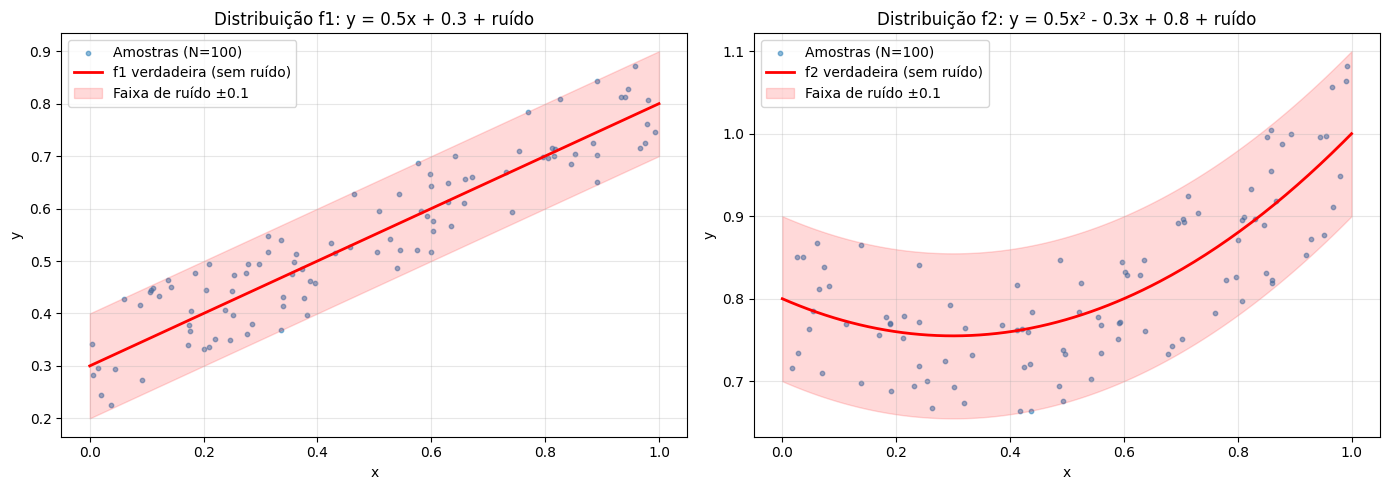

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_line = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)
y_true_f1 = 0.5 * x_line + 0.3
y_true_f2 = 0.5 * x_line**2 - 0.3 * x_line + 0.8

# f1
ax = axes[0]
x_sample, y_sample = datasets_f1[100]
ax.scatter(x_sample, y_sample, alpha=0.5, s=10, label="Amostras (N=100)")
ax.plot(x_line, y_true_f1, "r-", linewidth=2, label="f1 verdadeira (sem ruído)")
ax.fill_between(x_line.flatten(), (y_true_f1 - 0.1).flatten(), (y_true_f1 + 0.1).flatten(),
                alpha=0.15, color="red", label="Faixa de ruído ±0.1")
ax.set_title("Distribuição f1: y = 0.5x + 0.3 + ruído")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); ax.grid(True, alpha=0.3)

# f2
ax = axes[1]
x_sample, y_sample = datasets_f2[100]
ax.scatter(x_sample, y_sample, alpha=0.5, s=10, label="Amostras (N=100)")
ax.plot(x_line, y_true_f2, "r-", linewidth=2, label="f2 verdadeira (sem ruído)")
ax.fill_between(x_line.flatten(), (y_true_f2 - 0.1).flatten(), (y_true_f2 + 0.1).flatten(),
                alpha=0.15, color="red", label="Faixa de ruído ±0.1")
ax.set_title("Distribuição f2: y = 0.5x² - 0.3x + 0.8 + ruído")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Etapa 2 - Definição dos Modelos

Três modelos com ativação **linear** (identidade) em todas as camadas:

| Modelo | Arquitetura | Parâmetros |
|--------|------------|------------|
| **A** | 1 neurônio (regressão linear simples) | 2 |
| **B** | 1→2→1 (2 neurônios na camada escondida) | 7 |
| **C** | 1→30→1 (30 neurônios na camada escondida) | 91 |

**Importante:** Os pesos iniciais são salvos em backup antes de qualquer treino. Antes de cada novo treino, os pesos são restaurados a partir do backup, garantindo:
- Inicialização idêntica em todos os experimentos
- Nenhum modelo "herda" aprendizado de treinos anteriores

In [4]:
class ModelA(nn.Module):
    """Modelo A: apenas um neurônio (regressão linear simples)."""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

class ModelB(nn.Module):
    """Modelo B: 2 neurônios na camada escondida + 1 de saída. Ativação linear."""
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 2)
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        x = self.hidden(x)  # ativação linear (identidade)
        return self.output(x)

class ModelC(nn.Module):
    """Modelo C: 30 neurônios na camada escondida + 1 de saída. Ativação linear."""
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 30)
        self.output = nn.Linear(30, 1)

    def forward(self, x):
        x = self.hidden(x)  # ativação linear (identidade)
        return self.output(x)

# Criar modelos e salvar backup dos pesos iniciais
torch.manual_seed(42)
model_a_backup = copy.deepcopy(ModelA().state_dict())
torch.manual_seed(42)
model_b_backup = copy.deepcopy(ModelB().state_dict())
torch.manual_seed(42)
model_c_backup = copy.deepcopy(ModelC().state_dict())

model_configs = {
    "A": (ModelA, model_a_backup),
    "B": (ModelB, model_b_backup),
    "C": (ModelC, model_c_backup),
}

for name, (cls, _) in model_configs.items():
    m = cls()
    n_params = sum(p.numel() for p in m.parameters())
    print(f"Modelo {name}: {n_params} parâmetros")

Modelo A: 2 parâmetros
Modelo B: 7 parâmetros
Modelo C: 91 parâmetros


### Funções de treino e avaliação

- **Otimizador:** Adam (lr=0.01) — padronizado para todos os modelos
- **Épocas:** 2000 — critério de parada fixo para não favorecer nenhum modelo
- **Loss de treino:** MSE
- **Métricas de avaliação:** MSE, MAE, RMSE

In [5]:
def train_model(model, x_train, y_train, epochs=2000, lr=0.01):
    """Treina o modelo e retorna o loss final de treino."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    x_t = torch.tensor(x_train)
    y_t = torch.tensor(y_train)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(x_t)
        loss = criterion(pred, y_t)
        loss.backward()
        optimizer.step()

    # Loss final de treino
    model.eval()
    with torch.no_grad():
        pred = model(x_t)
        train_loss = criterion(pred, y_t).item()

    return train_loss

def evaluate_model(model, x_test, y_test):
    """Avalia o modelo e retorna MSE, MAE e RMSE."""
    model.eval()
    x_t = torch.tensor(x_test)
    y_t = torch.tensor(y_test)

    with torch.no_grad():
        pred = model(x_t)
        mse = nn.MSELoss()(pred, y_t).item()
        mae = torch.mean(torch.abs(pred - y_t)).item()
        rmse = np.sqrt(mse)

    return {"mse": mse, "mae": mae, "rmse": rmse, "predictions": pred.numpy()}

## Etapas 2 e 3 - Treinamento e Avaliação

Treinar cada modelo (A, B, C) em cada tamanho de amostra, para ambas as distribuições (f1 e f2).
Após o treino, avaliar em 1000 amostras de teste para simular o erro de generalização.

In [6]:
results = {}  # results[(func_name, model_name, n_samples)] = {...}

for func_name, datasets, test_x, test_y in [
    ("f1", datasets_f1, test_x_f1, test_y_f1),
    ("f2", datasets_f2, test_x_f2, test_y_f2),
]:
    print(f"\n{'='*60}")
    print(f"Treinando modelos para {func_name.upper()}")
    print(f"{'='*60}")
    for model_name, (ModelClass, backup_state) in model_configs.items():
        for n in SAMPLE_SIZES:
            x_train, y_train = datasets[n]

            # Restaurar pesos iniciais (backup)
            model = ModelClass()
            model.load_state_dict(copy.deepcopy(backup_state))

            # Treinar
            train_loss = train_model(model, x_train, y_train)

            # Avaliar no treino
            train_metrics = evaluate_model(model, x_train, y_train)

            # Avaliar no teste (1000 amostras)
            test_metrics = evaluate_model(model, test_x, test_y)

            results[(func_name, model_name, n)] = {
                "train_mse": train_loss,
                "train_mae": train_metrics["mae"],
                "train_rmse": train_metrics["rmse"],
                "test_mse": test_metrics["mse"],
                "test_mae": test_metrics["mae"],
                "test_rmse": test_metrics["rmse"],
            }

            print(f"Modelo {model_name} | N={n:>3d} | "
                  f"Train MSE={train_loss:.6f} | Test MSE={test_metrics['mse']:.6f} | "
                  f"Test MAE={test_metrics['mae']:.6f}")


Treinando modelos para F1


Modelo A | N=  2 | Train MSE=0.000000 | Test MSE=0.003605 | Test MAE=0.051142


Modelo A | N=  5 | Train MSE=0.001752 | Test MSE=0.003372 | Test MAE=0.050300


Modelo A | N= 10 | Train MSE=0.001811 | Test MSE=0.004757 | Test MAE=0.057779


Modelo A | N= 20 | Train MSE=0.002237 | Test MSE=0.003318 | Test MAE=0.049999


...

Modelo C | N=300 | Train MSE=0.004533 | Test MSE=0.004696 | Test MAE=0.056657


Modelo C | N=350 | Train MSE=0.004791 | Test MSE=0.004775 | Test MAE=0.056932


Modelo C | N=400 | Train MSE=0.004382 | Test MSE=0.004749 | Test MAE=0.056969


Modelo C | N=450 | Train MSE=0.004633 | Test MSE=0.004706 | Test MAE=0.056711


Modelo C | N=500 | Train MSE=0.004686 | Test MSE=0.004699 | Test MAE=0.056612


### Constantes de referência do risco real

In [7]:
REAL_MAE = 0.1  # conforme enunciado (amplitude máxima do ruído)
# Nota: o MAE teórico esperado do ruído E[|U(-0.1,0.1)|] = 0.05
# O enunciado define MAE real = 0.1, que corresponde à amplitude máxima do ruído ±0.1

# MSE teórico do ruído: Var(U(-0.1,0.1)) = (0.2)^2/12 = 1/300 ≈ 0.00333
REAL_MSE = (0.2**2) / 12

print(f"Risco real (MSE do ruído irredutível): {REAL_MSE:.6f}")
print(f"RMSE do ruído irredutível: {np.sqrt(REAL_MSE):.6f}")
print(f"MAE real (conforme enunciado): {REAL_MAE}")
print(f"MAE teórico esperado E[|U(-0.1,0.1)|]: 0.05")

Risco real (MSE do ruído irredutível): 0.003333
RMSE do ruído irredutível: 0.057735
MAE real (conforme enunciado): 0.1
MAE teórico esperado E[|U(-0.1,0.1)|]: 0.05


### Gráficos: Erro de Treino vs Erro de Teste (MSE, MAE, RMSE)

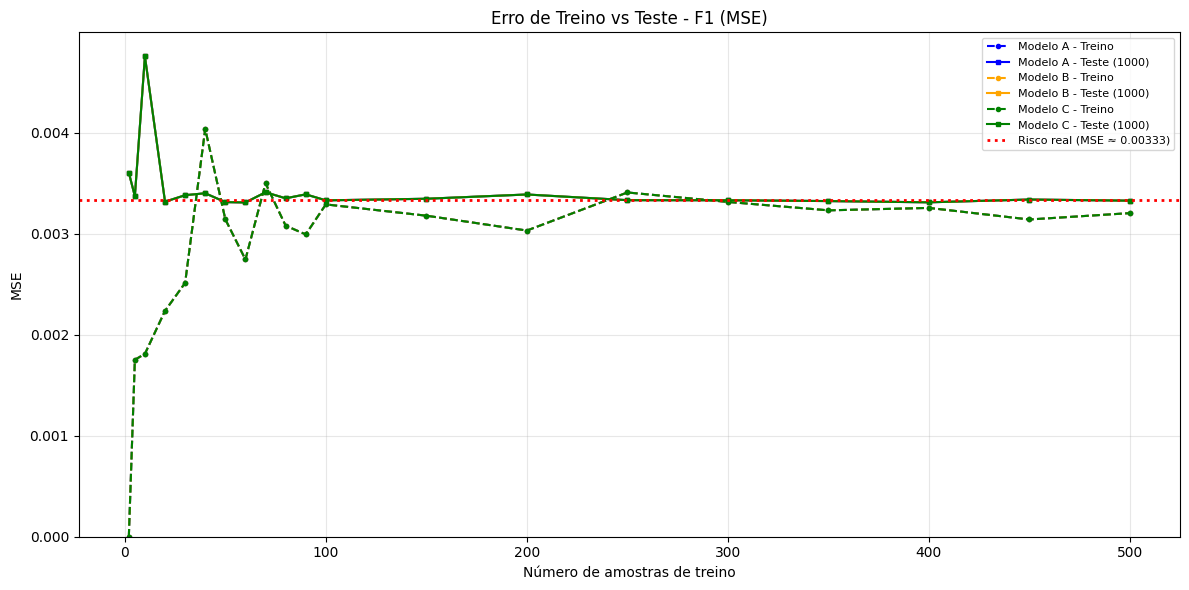

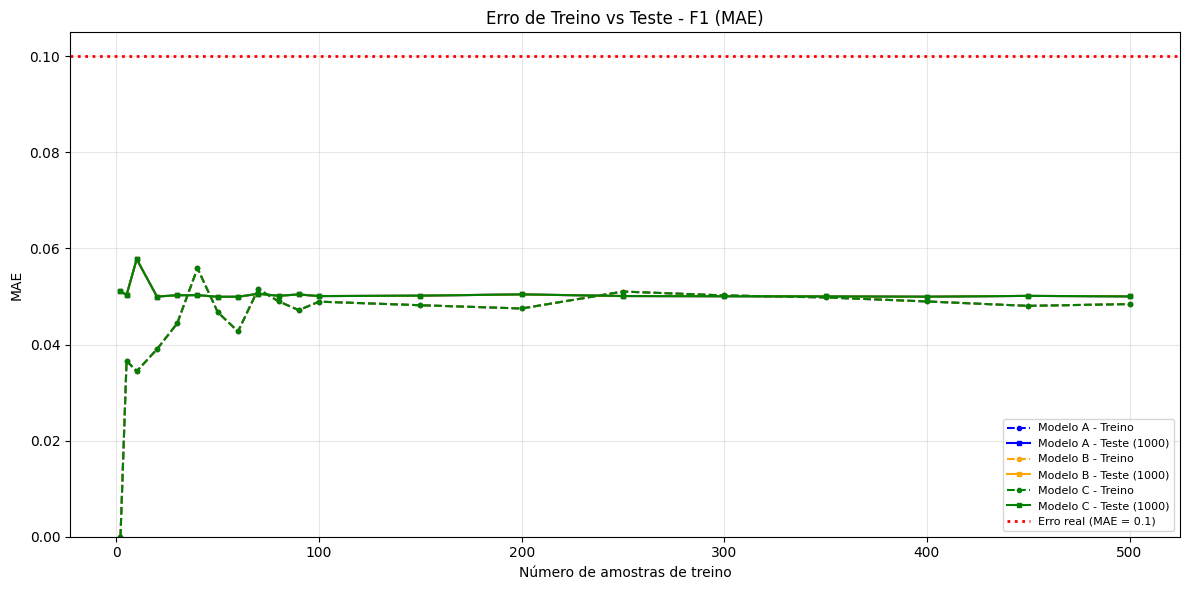

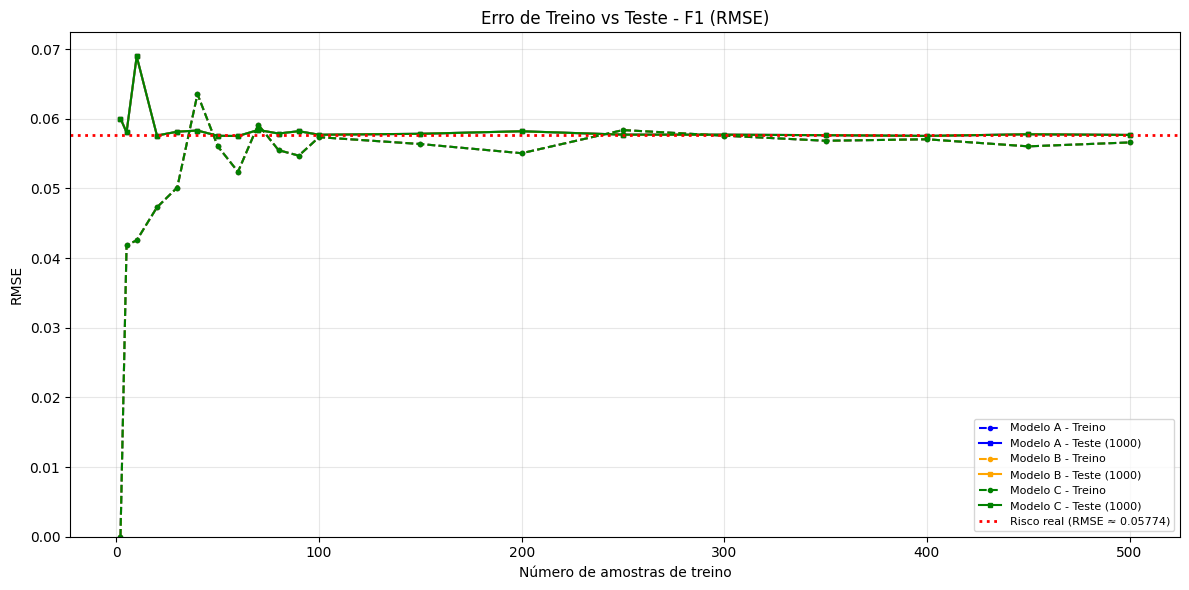

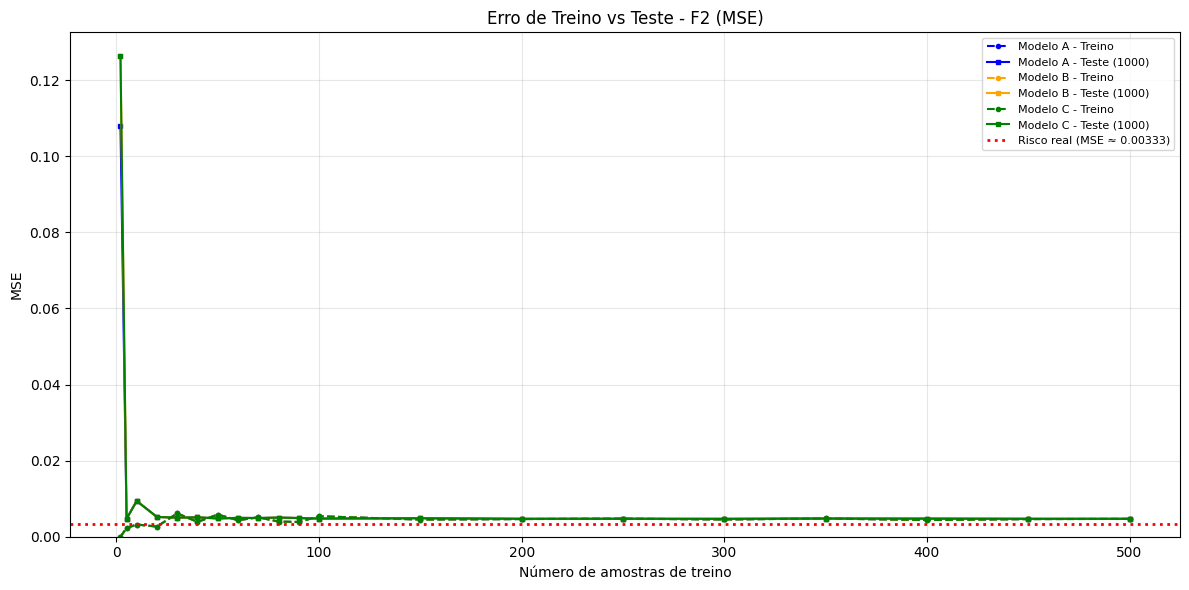

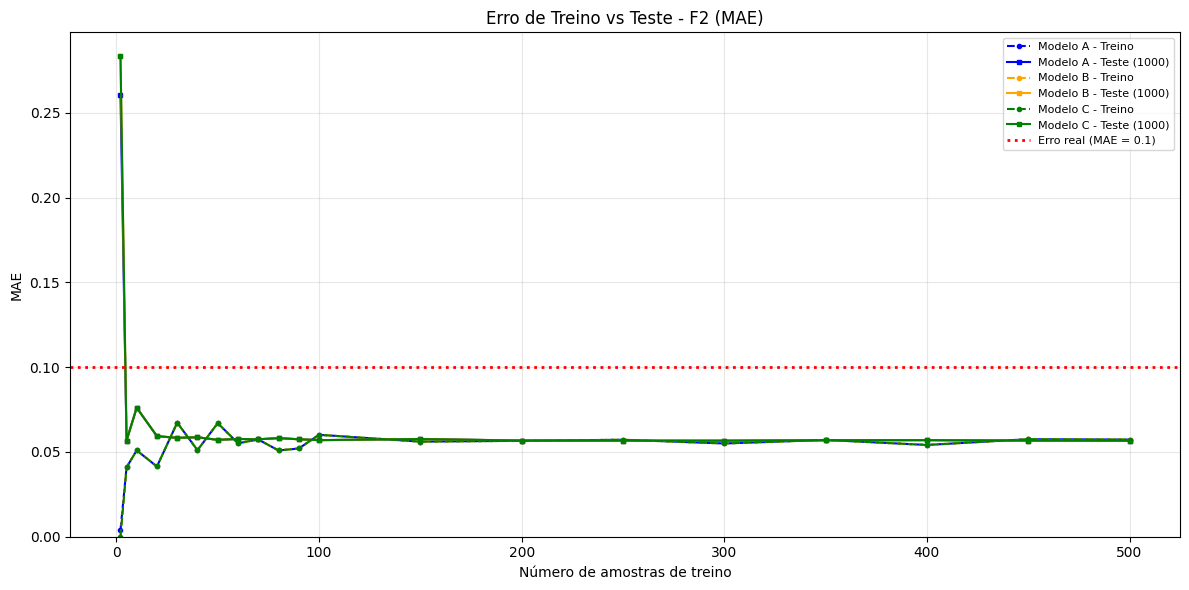

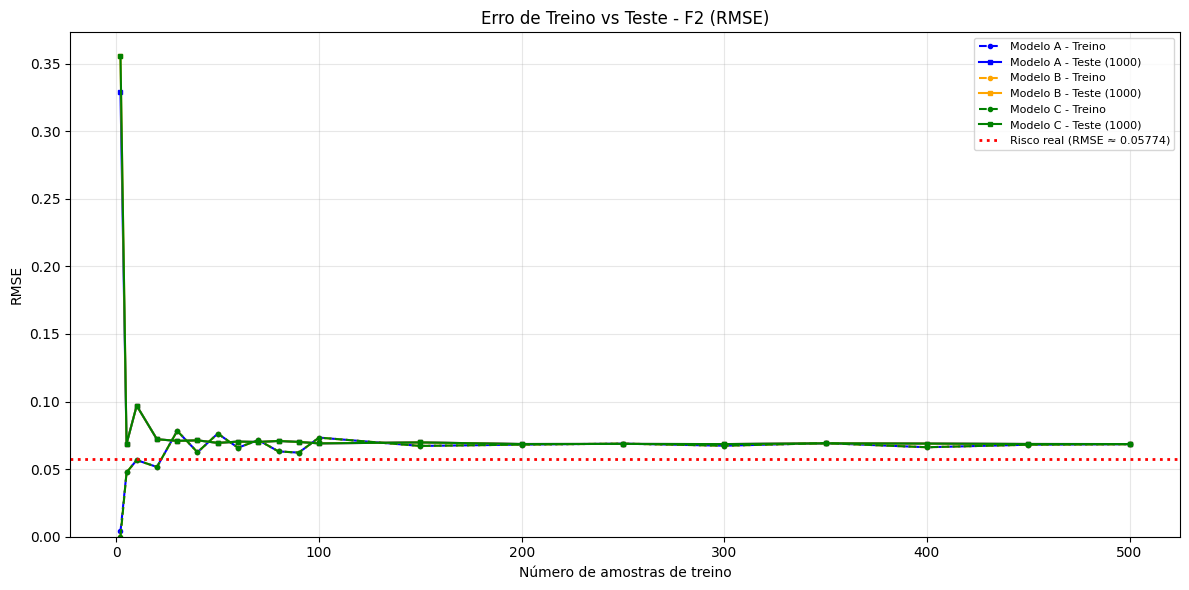

In [8]:
def plot_train_vs_test(func_name, metric="mse", ylabel="MSE"):
    """Gráfico de erro de treino vs teste para cada modelo."""
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = {"A": "blue", "B": "orange", "C": "green"}

    for model_name in ["A", "B", "C"]:
        train_vals = [results[(func_name, model_name, n)][f"train_{metric}"] for n in SAMPLE_SIZES]
        test_vals = [results[(func_name, model_name, n)][f"test_{metric}"] for n in SAMPLE_SIZES]

        ax.plot(SAMPLE_SIZES, train_vals, "--", color=colors[model_name],
                label=f"Modelo {model_name} - Treino", marker="o", markersize=3)
        ax.plot(SAMPLE_SIZES, test_vals, "-", color=colors[model_name],
                label=f"Modelo {model_name} - Teste (1000)", marker="s", markersize=3)

    if metric == "mae":
        ax.axhline(y=REAL_MAE, color="red", linestyle=":", linewidth=2,
                    label=f"Erro real (MAE = {REAL_MAE})")
    elif metric == "mse":
        ax.axhline(y=REAL_MSE, color="red", linestyle=":", linewidth=2,
                    label=f"Risco real (MSE ≈ {REAL_MSE:.5f})")
    elif metric == "rmse":
        ax.axhline(y=np.sqrt(REAL_MSE), color="red", linestyle=":", linewidth=2,
                    label=f"Risco real (RMSE ≈ {np.sqrt(REAL_MSE):.5f})")

    ax.set_xlabel("Número de amostras de treino")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Erro de Treino vs Teste - {func_name.upper()} ({ylabel})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    plt.show()

for func_name in ["f1", "f2"]:
    for metric, ylabel in [("mse", "MSE"), ("mae", "MAE"), ("rmse", "RMSE")]:
        plot_train_vs_test(func_name, metric, ylabel)

### Gráfico: Gap de Generalização (Teste - Treino)

O gap positivo indica overfitting: o modelo se ajusta demais ao treino e generaliza mal.

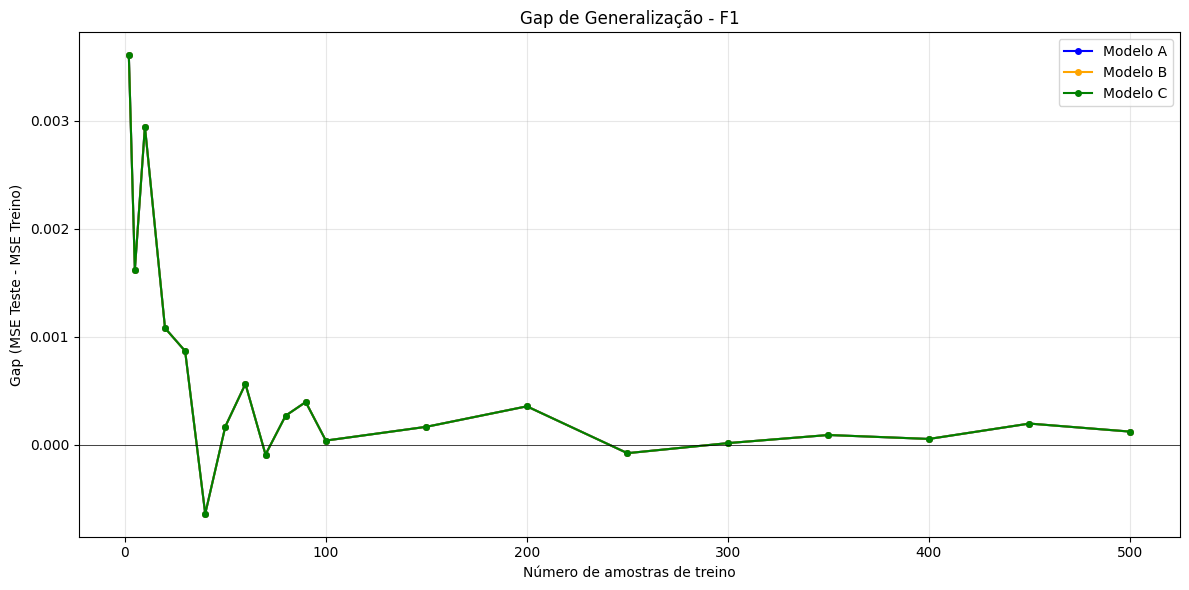

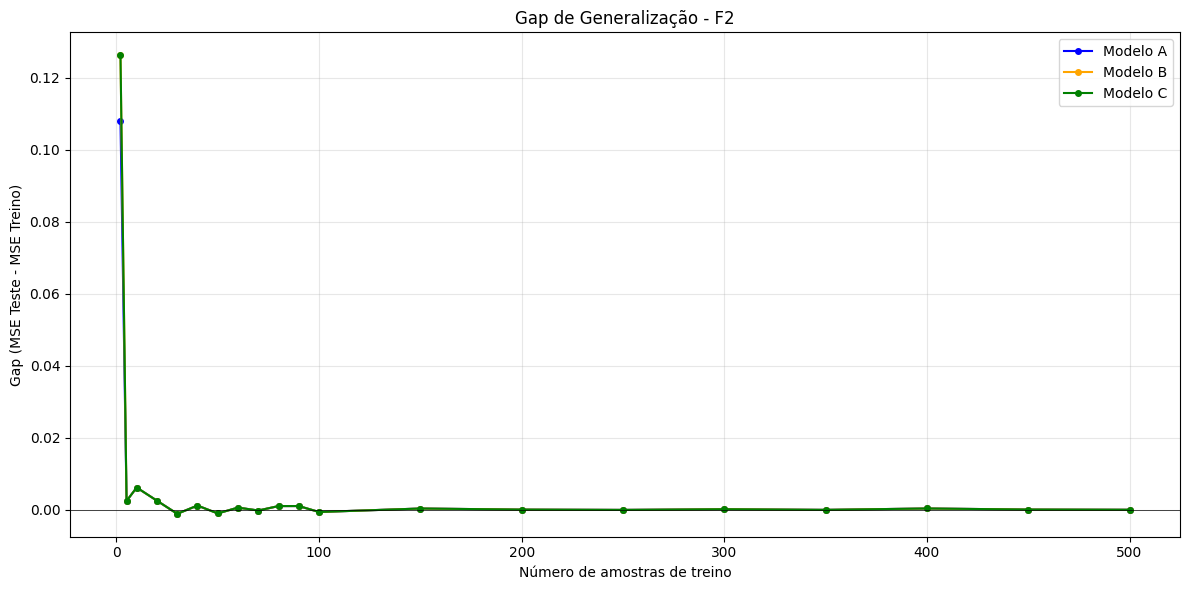

In [9]:
for func_name in ["f1", "f2"]:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = {"A": "blue", "B": "orange", "C": "green"}

    for model_name in ["A", "B", "C"]:
        gaps = [
            results[(func_name, model_name, n)]["test_mse"] -
            results[(func_name, model_name, n)]["train_mse"]
            for n in SAMPLE_SIZES
        ]
        ax.plot(SAMPLE_SIZES, gaps, "-o", color=colors[model_name],
                label=f"Modelo {model_name}", markersize=4)

    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.set_xlabel("Número de amostras de treino")
    ax.set_ylabel("Gap (MSE Teste - MSE Treino)")
    ax.set_title(f"Gap de Generalização - {func_name.upper()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

### Visualização das predições dos modelos

Comparação visual das predições de cada modelo contra a função verdadeira, para diferentes tamanhos de amostra.

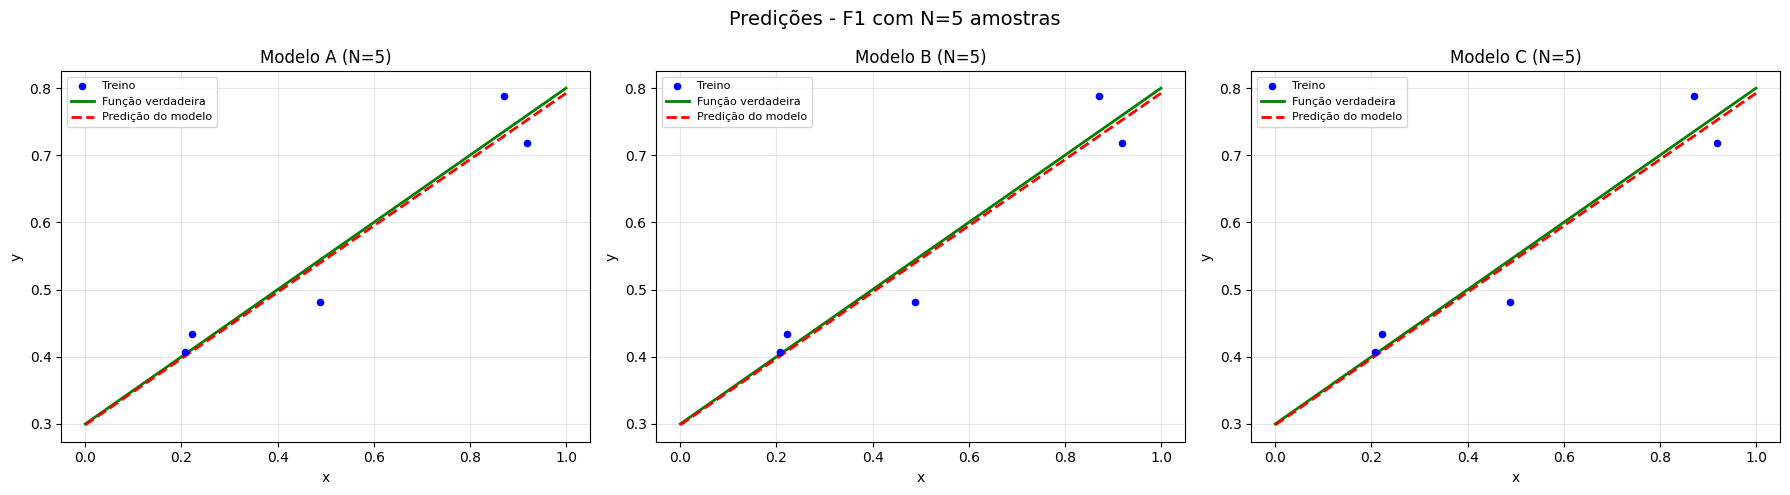

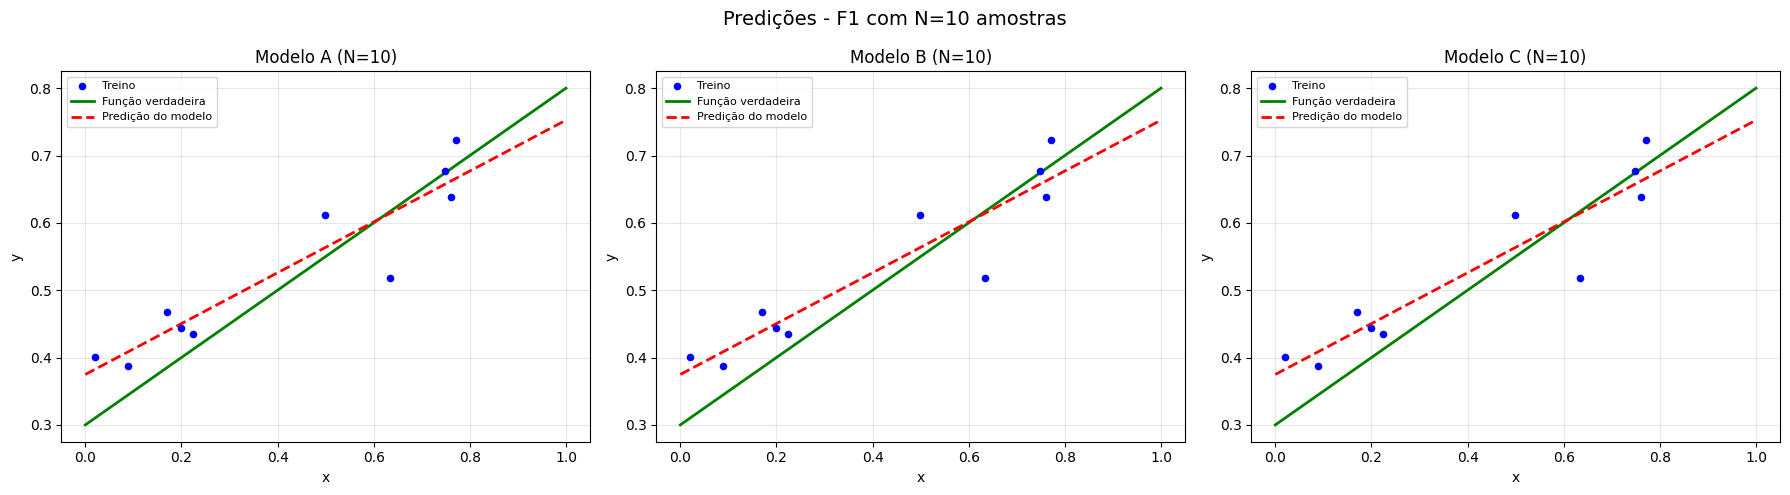

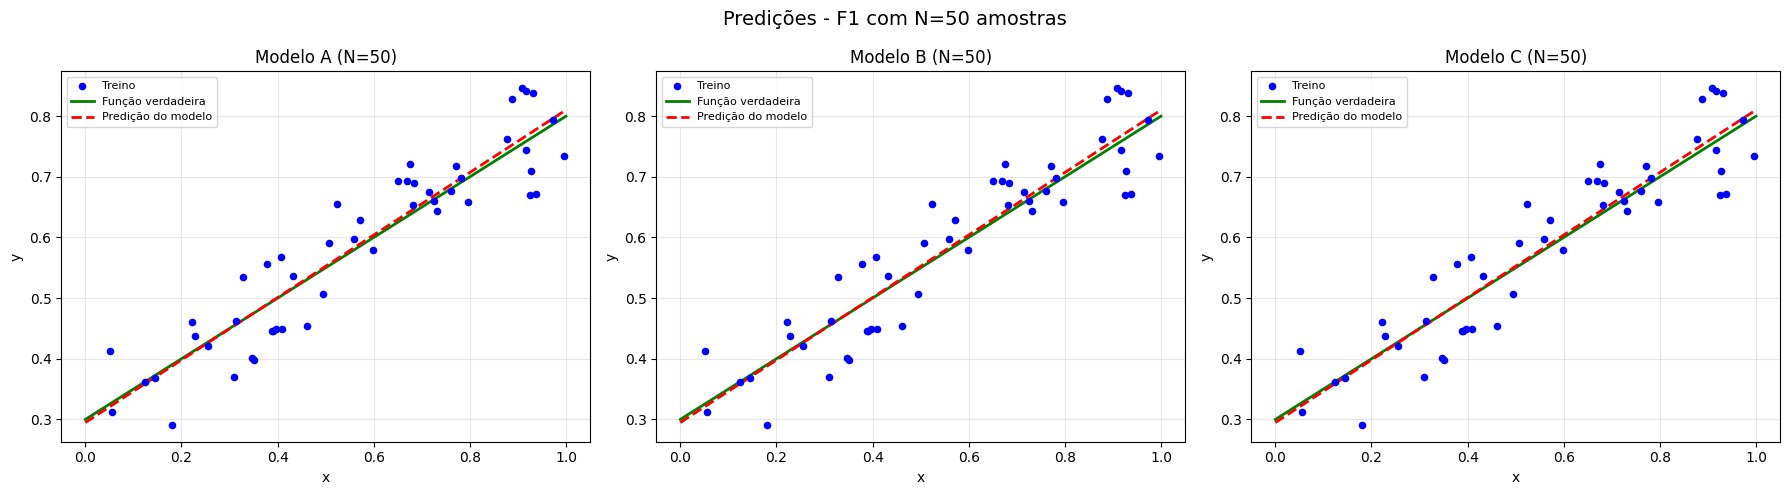

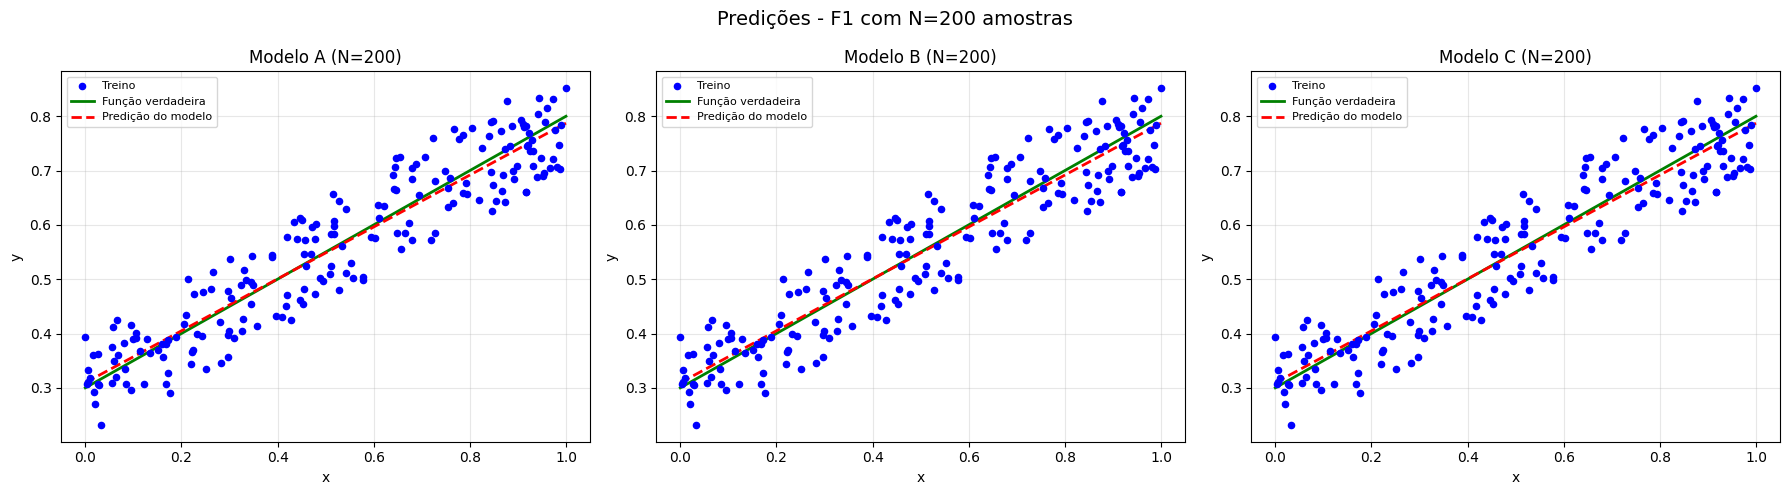

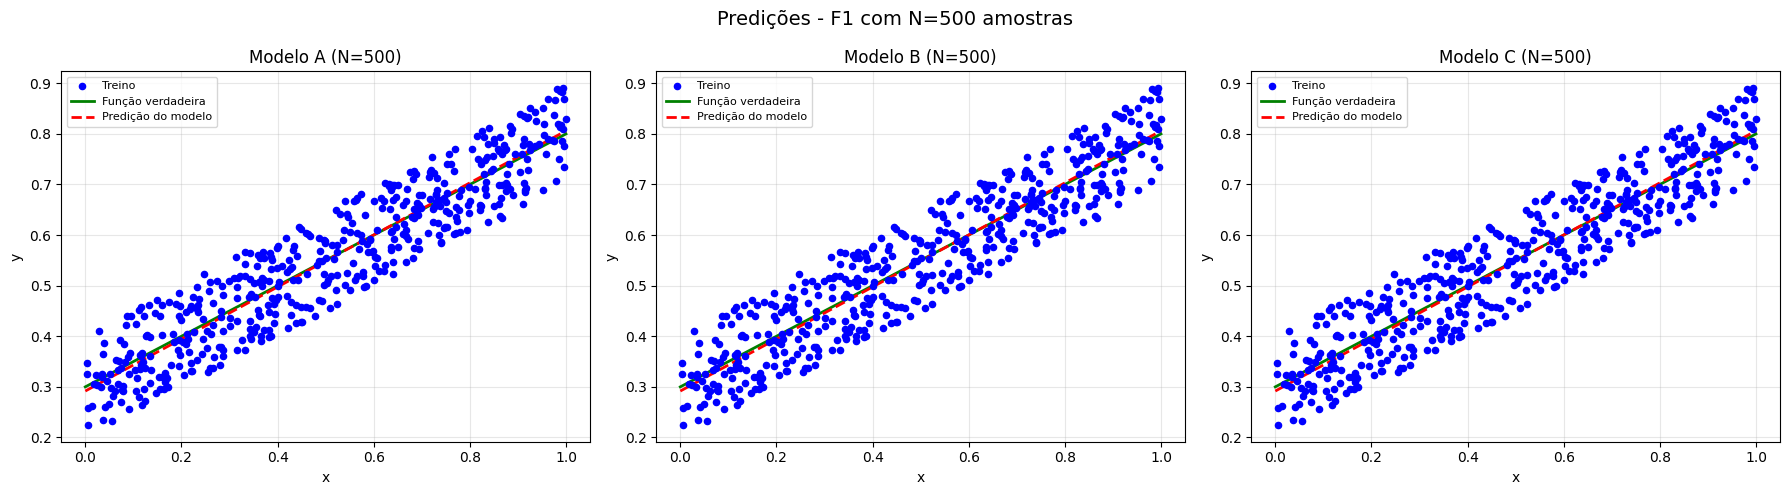

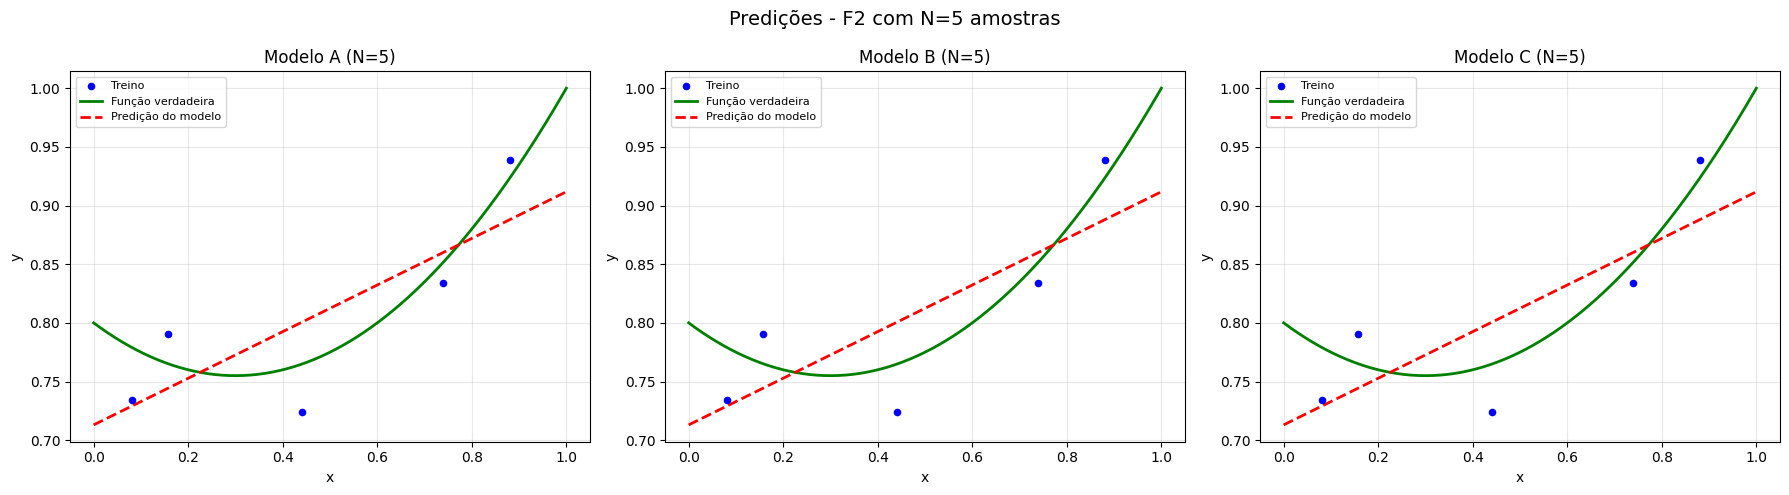

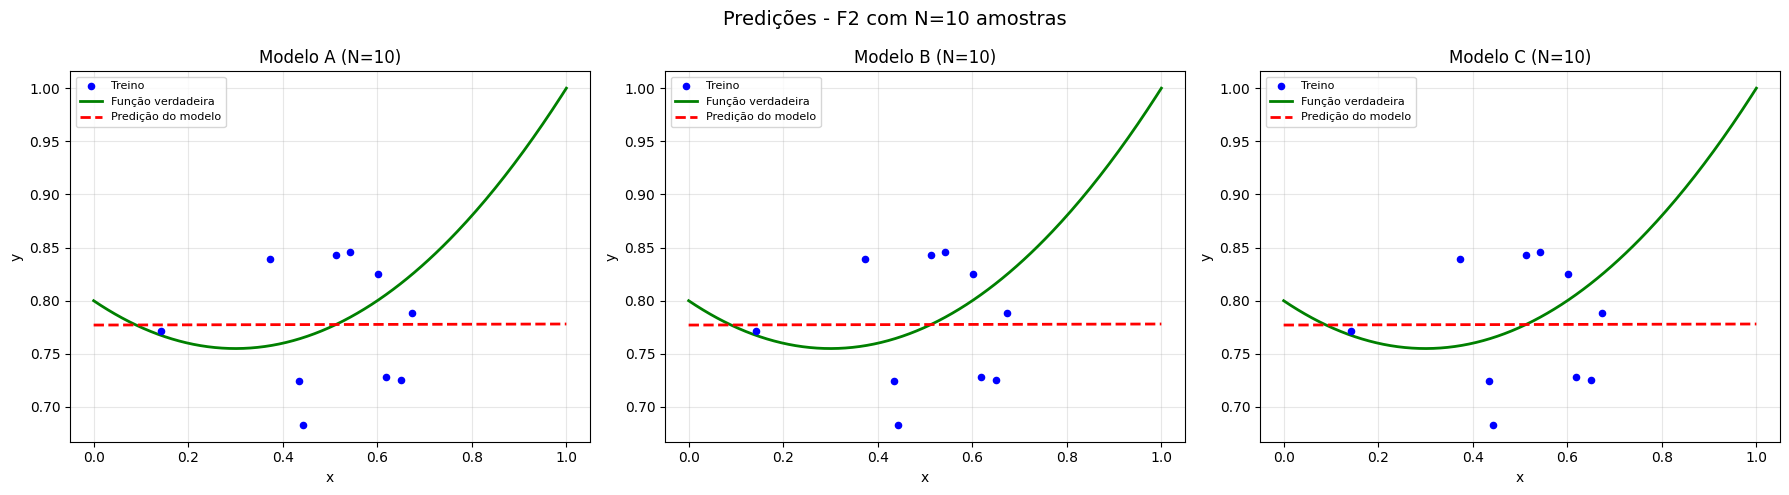

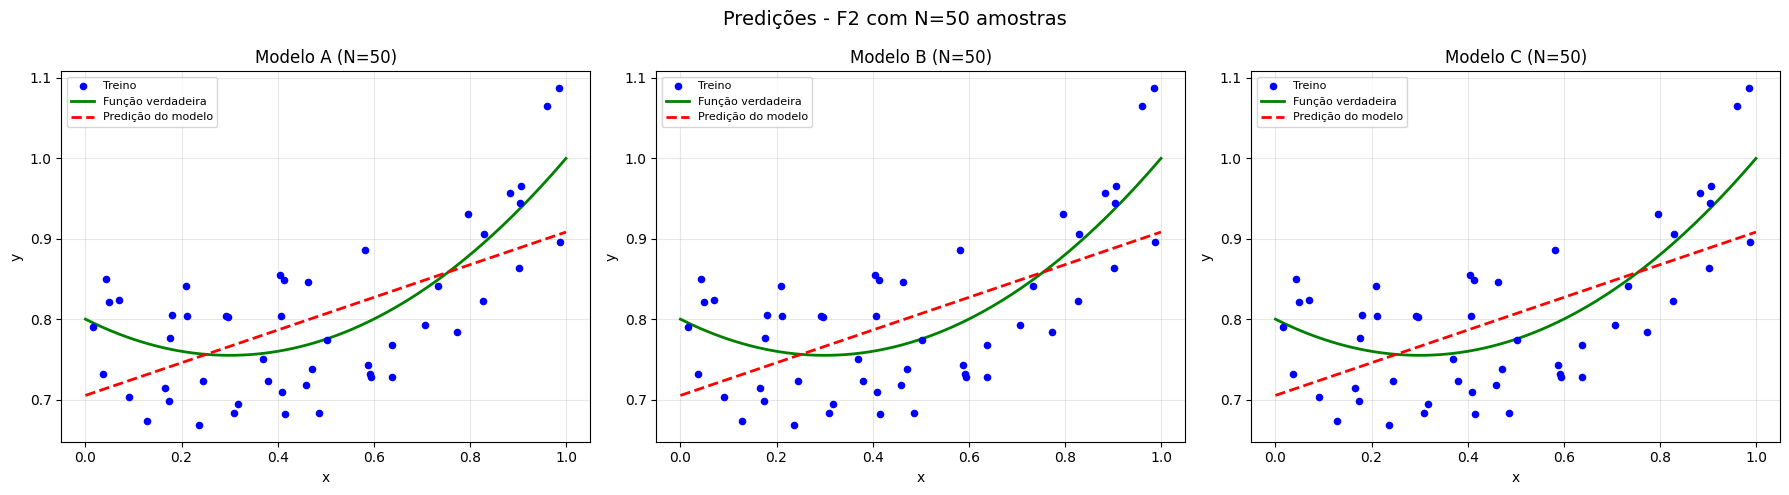

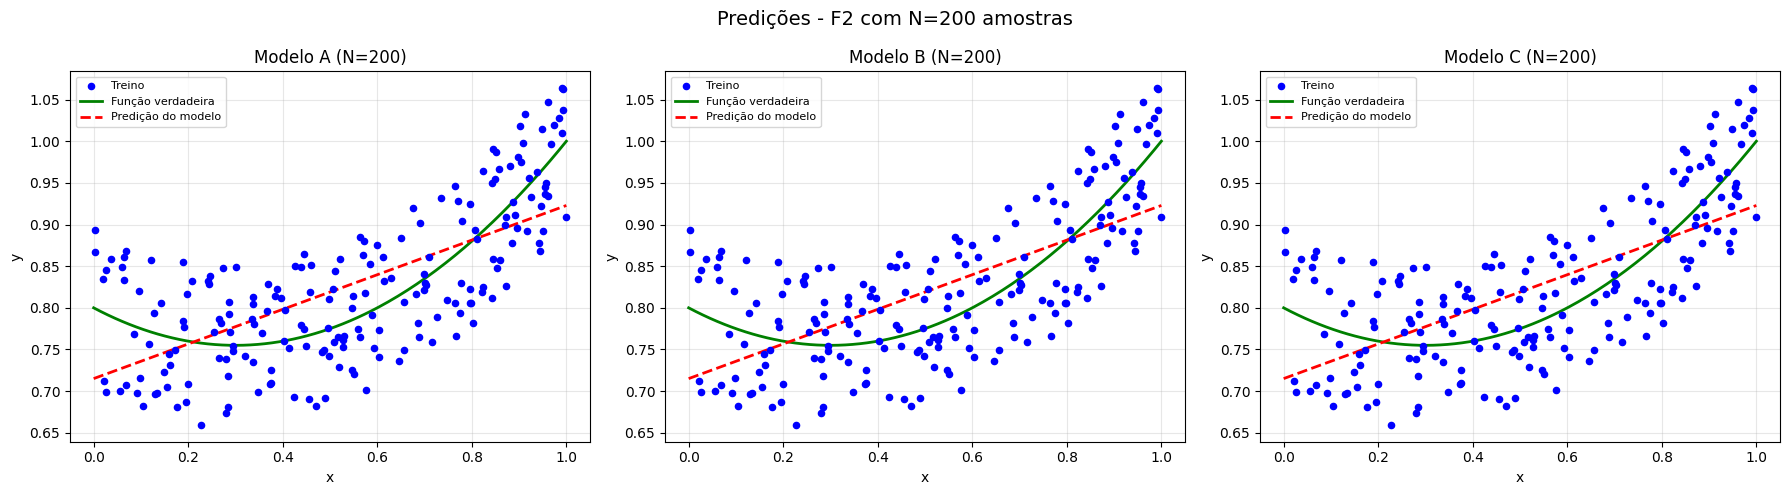

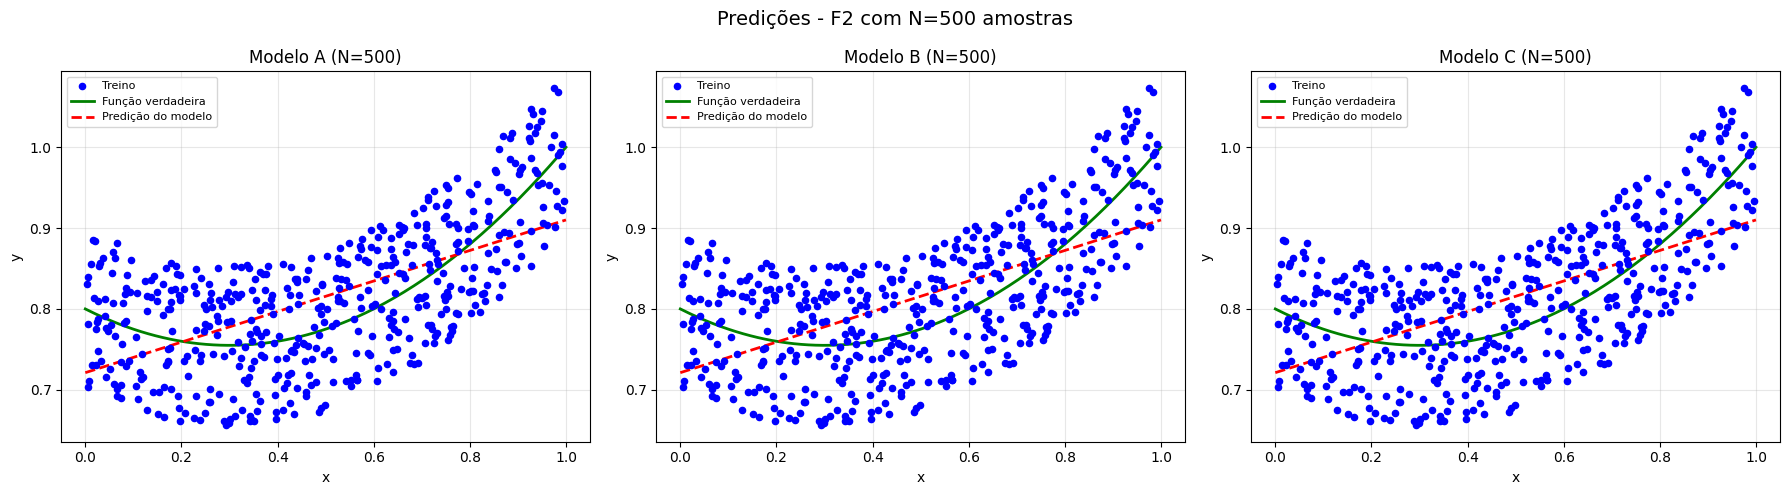

In [10]:
x_line = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)

for func_name, datasets, test_x, test_y in [("f1", datasets_f1, test_x_f1, test_y_f1),
                                              ("f2", datasets_f2, test_x_f2, test_y_f2)]:
    if func_name == "f1":
        y_true = 0.5 * x_line + 0.3
    else:
        y_true = 0.5 * x_line**2 - 0.3 * x_line + 0.8

    for n_sample in [5, 10, 50, 200, 500]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        x_train, y_train = datasets[n_sample]

        for idx, model_name in enumerate(["A", "B", "C"]):
            ax = axes[idx]
            ModelClass, backup_state = model_configs[model_name]
            model = ModelClass()
            model.load_state_dict(copy.deepcopy(backup_state))
            train_model(model, x_train, y_train)

            model.eval()
            with torch.no_grad():
                y_pred_line = model(torch.tensor(x_line)).numpy()

            ax.scatter(x_train, y_train, color="blue", s=20, label="Treino", zorder=5)
            ax.plot(x_line, y_true, "g-", linewidth=2, label="Função verdadeira")
            ax.plot(x_line, y_pred_line, "r--", linewidth=2, label="Predição do modelo")
            ax.set_title(f"Modelo {model_name} (N={n_sample})")
            ax.set_xlabel("x"); ax.set_ylabel("y")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        fig.suptitle(f"Predições - {func_name.upper()} com N={n_sample} amostras", fontsize=14)
        fig.tight_layout()
        plt.show()

### Tabela Resumo: Risco Esperado vs Simulado vs Real

In [11]:
for func_name in ["f1", "f2"]:
    print(f"\n{'='*90}")
    print(f"  TABELA RESUMO - {func_name.upper()}")
    print(f"{'='*90}")
    print(f"{'Modelo':<8} {'N':>5} {'MSE Treino':>12} {'MSE Teste':>12} {'MAE Teste':>12} "
          f"{'RMSE Teste':>12} {'MSE Real':>10} {'MAE Real':>10}")
    print("-" * 90)
    for model_name in ["A", "B", "C"]:
        for n in SAMPLE_SIZES:
            r = results[(func_name, model_name, n)]
            print(f"{model_name:<8} {n:>5d} {r['train_mse']:>12.6f} {r['test_mse']:>12.6f} "
                  f"{r['test_mae']:>12.6f} {r['test_rmse']:>12.6f} {REAL_MSE:>10.6f} {REAL_MAE:>10.1f}")
        print()


  TABELA RESUMO - F1
Modelo       N   MSE Treino    MSE Teste    MAE Teste   RMSE Teste   MSE Real   MAE Real
------------------------------------------------------------------------------------------
A            2     0.000000     0.003605     0.051142     0.060045   0.003333        0.1
A            5     0.001752     0.003372     0.050300     0.058071   0.003333        0.1
A           10     0.001811     0.004757     0.057779     0.068974   0.003333        0.1
A           20     0.002237     0.003318     0.049999     0.057603   0.003333        0.1
A           30     0.002513     0.003382     0.050266     0.058158   0.003333        0.1
A           40     0.004039     0.003401     0.050290     0.058322   0.003333        0.1
A           50     0.003144     0.003314     0.049949     0.057567   0.003333        0.1
A           60     0.002746     0.003310     0.049953     0.057536   0.003333        0.1
A           70     0.003500     0.003411     0.050575     0.058406   0.003333        0

## Discussão Inicial

### Equivalência matemática dos modelos lineares

Um ponto fundamental para interpretar os resultados é que **todos os três modelos (A, B e C), usando apenas ativação linear (identidade), são matematicamente equivalentes em capacidade expressiva**. A composição de transformações lineares é uma transformação linear:

$$f(x) = W_2 \cdot (W_1 \cdot x + b_1) + b_2 = (W_2 W_1) \cdot x + (W_2 b_1 + b_2) = W' \cdot x + b'$$

Portanto, independentemente de quantos neurônios existam nas camadas escondidas, os modelos B e C com ativação linear são equivalentes ao Modelo A (regressão linear simples). Os gráficos de predição confirmam isso: as curvas de predição dos três modelos são praticamente idênticas — todas são retas.

### Os três tipos de risco

- **Risco empírico (loss no treino):** O erro calculado nos dados usados para treinar. Tende a ser **otimista** porque o modelo foi ajustado para minimizar exatamente esse erro. Com poucos dados, o modelo pode atingir um loss de treino muito baixo sem realmente aprender o padrão subjacente.

- **Risco simulado (loss nas 1000 amostras):** Aproxima o verdadeiro erro de generalização usando dados não vistos durante o treino. Com 1000 amostras, temos uma estimativa estatisticamente robusta do desempenho em dados novos.

- **Risco real (ruído irredutível):** O menor erro possível, ditado pelo ruído intrínseco da distribuição geradora. Para o nosso ruído U(-0.1, 0.1):
  - **MSE irredutível** = Var(ruído) = (0.2)²/12 ≈ 0.00333
  - **MAE** = 0.1 (conforme definido no enunciado — corresponde à amplitude máxima do ruído; o MAE teórico esperado E[|U(-0.1,0.1)|] = 0.05)

### Comportamento em f1 (linear)

Para f1(x) = 0.5x + 0.3 + ruído, a função geradora é **linear**. Como todos os modelos são lineares:
- Os modelos conseguem aprender a relação verdadeira (são adequados para a tarefa).
- Com amostras suficientes (N ≥ ~30), tanto o erro de treino quanto o de teste convergem para valores próximos ao ruído irredutível (~0.00333 MSE).
- Com **poucas amostras** (N=2, 5), o loss de treino pode ser muito baixo (o modelo ajusta a reta perfeitamente aos poucos pontos), mas o loss de teste será maior — este é o gap de generalização. Porém, como o modelo é linear e a função verdadeira também é, esse gap não é overfitting clássico (memorização de padrões espúrios), mas sim instabilidade estatística por amostragem insuficiente.
- O **fitting é adequado** para f1: os modelos lineares possuem o viés correto para esta tarefa.

### Comportamento em f2 (quadrática)

Para f2(x) = 0.5x² - 0.3x + 0.8 + ruído, a função geradora é **quadrática**. Modelos lineares não conseguem capturar a curvatura:
- **Underfitting sistemático:** O erro de teste permanece acima do ruído irredutível mesmo com muitos dados (N=500), pois a reta é a melhor aproximação linear da parábola, mas nunca será perfeita.
- O **viés do modelo** (bias) é o componente dominante do erro — a diferença entre a melhor reta possível e a verdadeira parábola.
- Os gráficos de predição mostram claramente: as retas cruzam a curva verdadeira mas divergem nas extremidades, gerando erro sistemático.
- O gap de generalização para f2 não converge a zero porque o erro de treino também subestima o viés (a reta se ajusta aos pontos vistos, mas erra sistematicamente nos não vistos).

### Overfitting, Underfitting e Fitting Adequado

| Situação | Erro Treino | Erro Teste | Onde observar |
|----------|-------------|------------|---------------|
| **Underfitting** | Alto | Alto | Modelos A, B, C em f2 (linear tentando aprender quadrática) |
| **Fitting adequado** | Próximo ao risco real | Próximo ao risco real | Modelos A, B, C em f1 com N ≥ 30 |
| **Overfitting** | Muito baixo | Alto (gap grande) | Difícil de observar aqui com ativação linear, pois os modelos não têm capacidade de memorizar — será mais evidente com ReLU e poucos dados |

### Impacto da quantidade de amostras

- O **gap de generalização** (teste - treino) diminui conforme N aumenta, para ambas as funções.
- Em f1, o erro converge ao risco real com amostras suficientes.
- Em f2, mesmo com N=500, o erro de teste permanece elevado — evidência de que o problema é de **viés** (modelo inadequado), não de variância (dados insuficientes).
- A tabela resumo acima permite comparar numericamente: observe como o MSE de teste em f2 se estabiliza em um patamar bem acima de 0.00333, enquanto em f1 se aproxima desse valor.

---
## Experimento Extra 1: Impacto do aumento de camadas (ativação linear)

Testamos redes com 1, 2, 4 e 8 camadas escondidas (10 neurônios cada), todas com ativação linear.

**Hipótese:** Com ativação linear, empilhar camadas não aumenta a capacidade expressiva do modelo, pois composição de transformações lineares continua sendo linear (AB = C, uma única matriz).

In [12]:
class ModelDeep2(nn.Module):
    """2 camadas escondidas de 10 neurônios cada."""
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 1),
        )
    def forward(self, x):
        return self.layers(x)

class ModelDeep4(nn.Module):
    """4 camadas escondidas de 10 neurônios cada."""
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 1),
        )
    def forward(self, x):
        return self.layers(x)

class ModelDeep8(nn.Module):
    """8 camadas escondidas de 10 neurônios cada."""
    def __init__(self):
        super().__init__()
        layers = [nn.Linear(1, 10)]
        for _ in range(7):
            layers.append(nn.Linear(10, 10))
        layers.append(nn.Linear(10, 1))
        self.layers = nn.Sequential(*layers)
    def forward(self, x):
        return self.layers(x)

torch.manual_seed(42)
deep2_backup = copy.deepcopy(ModelDeep2().state_dict())
torch.manual_seed(42)
deep4_backup = copy.deepcopy(ModelDeep4().state_dict())
torch.manual_seed(42)
deep8_backup = copy.deepcopy(ModelDeep8().state_dict())

deep_configs = {
    "1 camada (B)": (ModelB, model_b_backup),
    "2 camadas": (ModelDeep2, deep2_backup),
    "4 camadas": (ModelDeep4, deep4_backup),
    "8 camadas": (ModelDeep8, deep8_backup),
}

SAMPLE_SIZES_EXTRA = [10, 50, 100, 200, 500]
results_depth = {}

for func_name, datasets, test_x, test_y in [
    ("f1", datasets_f1, test_x_f1, test_y_f1),
    ("f2", datasets_f2, test_x_f2, test_y_f2),
]:
    for depth_name, (ModelClass, backup_state) in deep_configs.items():
        for n in SAMPLE_SIZES_EXTRA:
            x_train, y_train = datasets[n]
            model = ModelClass()
            model.load_state_dict(copy.deepcopy(backup_state))
            train_loss = train_model(model, x_train, y_train)
            test_metrics = evaluate_model(model, test_x, test_y)

            results_depth[(func_name, depth_name, n)] = {
                "train_mse": train_loss,
                "test_mse": test_metrics["mse"],
                "test_mae": test_metrics["mae"],
            }
            print(f"{func_name} | {depth_name:<15} | N={n:>3d} | "
                  f"Train MSE={train_loss:.6f} | Test MSE={test_metrics['mse']:.6f}")

f1 | 1 camada (B)    | N= 10 | Train MSE=0.001811 | Test MSE=0.004757


f1 | 1 camada (B)    | N= 50 | Train MSE=0.003144 | Test MSE=0.003314


f1 | 1 camada (B)    | N=100 | Train MSE=0.003291 | Test MSE=0.003331


f1 | 1 camada (B)    | N=200 | Train MSE=0.003032 | Test MSE=0.003389


f1 | 1 camada (B)    | N=500 | Train MSE=0.003205 | Test MSE=0.003328


...

f2 | 8 camadas       | N= 10 | Train MSE=0.003212 | Test MSE=0.009399


f2 | 8 camadas       | N= 50 | Train MSE=0.005822 | Test MSE=0.004817


f2 | 8 camadas       | N=100 | Train MSE=0.005377 | Test MSE=0.004768


f2 | 8 camadas       | N=200 | Train MSE=0.004644 | Test MSE=0.004703


f2 | 8 camadas       | N=500 | Train MSE=0.004686 | Test MSE=0.004699


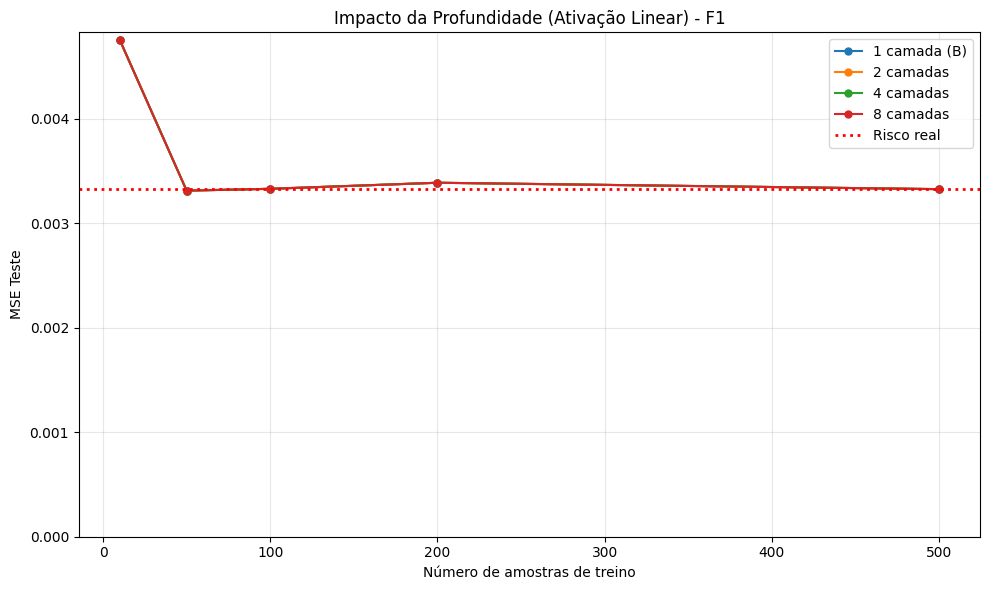

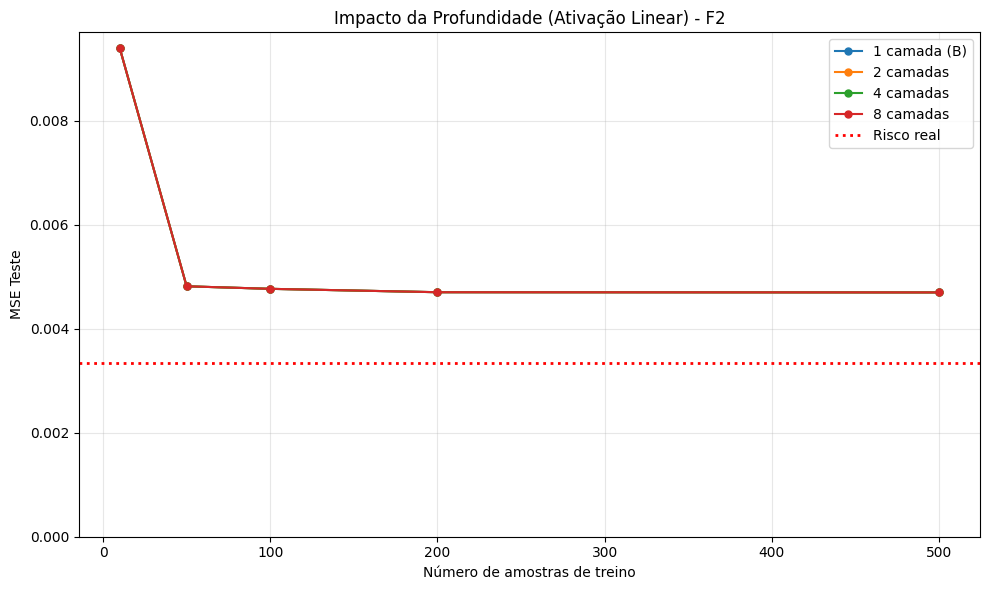

In [13]:
for func_name in ["f1", "f2"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    for depth_name in deep_configs:
        test_vals = [results_depth[(func_name, depth_name, n)]["test_mse"]
                     for n in SAMPLE_SIZES_EXTRA]
        ax.plot(SAMPLE_SIZES_EXTRA, test_vals, "-o", label=depth_name, markersize=5)

    ax.axhline(y=REAL_MSE, color="red", linestyle=":", linewidth=2, label="Risco real")
    ax.set_xlabel("Número de amostras de treino")
    ax.set_ylabel("MSE Teste")
    ax.set_title(f"Impacto da Profundidade (Ativação Linear) - {func_name.upper()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    plt.show()

### Análise: Impacto do aumento de camadas (ativação linear)

Conforme demonstrado na discussão inicial, com ativação linear, composição de camadas é equivalente a uma única transformação linear:

$$W_n \cdot W_{n-1} \cdot \ldots \cdot W_1 \cdot x + b = W' \cdot x + b'$$

**O que os gráficos acima mostram:**

1. **Capacidade expressiva idêntica:** Redes com 1, 2, 4 ou 8 camadas lineares produzem resultados essencialmente equivalentes — todas aprendem a mesma função linear. Isso é visível no MSE de teste, que se mantém no mesmo patamar independentemente da profundidade.

2. **Dificuldade crescente de otimização:** Embora a capacidade teórica seja a mesma, redes mais profundas podem apresentar **resultados piores** na prática. Isso ocorre porque:
   - A paisagem de otimização (loss landscape) se torna mais complexa e não-convexa com mais camadas, mesmo que o ótimo global seja o mesmo.
   - **Vanishing/exploding gradients:** ao retropropagar por muitas camadas lineares, os gradientes podem diminuir ou explodir, dificultando a convergência do otimizador.
   - O Adam com 2000 épocas pode não ser suficiente para que redes muito profundas (8 camadas) atinjam o mesmo mínimo que redes rasas.

3. **Conclusão para f1:** Todas as profundidades convergem para erro próximo ao risco real, pois o modelo linear é adequado. Diferenças entre profundidades são apenas artefatos de otimização.

4. **Conclusão para f2:** Nenhuma profundidade resolve o underfitting, pois o problema é de **viés** (modelo linear para função quadrática), não de capacidade. Adicionar camadas lineares não adiciona capacidade de aproximar não-linearidades.

**Lição principal:** Profundidade sem não-linearidade é redundante. A verdadeira utilidade de redes profundas requer funções de ativação não-lineares (como ReLU), que permitem que cada camada adicional aumente a capacidade expressiva.

---
## Experimento Extra 2: Impacto da mudança para ReLU

Comparamos os modelos B e C com ativação **linear** vs **ReLU** nas camadas escondidas.

**Hipótese:** A ReLU introduz não-linearidade, permitindo ao modelo aprender funções mais complexas. Isso deve beneficiar especialmente a f2 (quadrática), que modelos lineares não conseguem capturar.

In [14]:
class ModelB_ReLU(nn.Module):
    """Modelo B com ReLU: 2 neurônios escondidos + ReLU + 1 saída."""
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 2)
        self.relu = nn.ReLU()
        self.output = nn.Linear(2, 1)
    def forward(self, x):
        return self.output(self.relu(self.hidden(x)))

class ModelC_ReLU(nn.Module):
    """Modelo C com ReLU: 30 neurônios escondidos + ReLU + 1 saída."""
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 30)
        self.relu = nn.ReLU()
        self.output = nn.Linear(30, 1)
    def forward(self, x):
        return self.output(self.relu(self.hidden(x)))

class ModelDeep2_ReLU(nn.Module):
    """2 camadas escondidas com ReLU, 10 neurônios cada."""
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 10), nn.ReLU(),
            nn.Linear(10, 10), nn.ReLU(),
            nn.Linear(10, 1),
        )
    def forward(self, x):
        return self.layers(x)

torch.manual_seed(42)
model_b_relu_backup = copy.deepcopy(ModelB_ReLU().state_dict())
torch.manual_seed(42)
model_c_relu_backup = copy.deepcopy(ModelC_ReLU().state_dict())
torch.manual_seed(42)
deep2_relu_backup = copy.deepcopy(ModelDeep2_ReLU().state_dict())

relu_configs = {
    "B Linear": (ModelB, model_b_backup),
    "B ReLU": (ModelB_ReLU, model_b_relu_backup),
    "C Linear": (ModelC, model_c_backup),
    "C ReLU": (ModelC_ReLU, model_c_relu_backup),
}

results_relu = {}

for func_name, datasets, test_x, test_y in [
    ("f1", datasets_f1, test_x_f1, test_y_f1),
    ("f2", datasets_f2, test_x_f2, test_y_f2),
]:
    for relu_name, (ModelClass, backup_state) in relu_configs.items():
        for n in SAMPLE_SIZES_EXTRA:
            x_train, y_train = datasets[n]
            model = ModelClass()
            model.load_state_dict(copy.deepcopy(backup_state))
            train_loss = train_model(model, x_train, y_train)
            test_metrics = evaluate_model(model, test_x, test_y)

            results_relu[(func_name, relu_name, n)] = {
                "train_mse": train_loss,
                "test_mse": test_metrics["mse"],
                "test_mae": test_metrics["mae"],
            }
            print(f"{func_name} | {relu_name:<12} | N={n:>3d} | "
                  f"Train MSE={train_loss:.6f} | Test MSE={test_metrics['mse']:.6f} | "
                  f"Test MAE={test_metrics['mae']:.6f}")

f1 | B Linear     | N= 10 | Train MSE=0.001811 | Test MSE=0.004757 | Test MAE=0.057779


f1 | B Linear     | N= 50 | Train MSE=0.003144 | Test MSE=0.003314 | Test MAE=0.049949


f1 | B Linear     | N=100 | Train MSE=0.003291 | Test MSE=0.003331 | Test MAE=0.050091


f1 | B Linear     | N=200 | Train MSE=0.003032 | Test MSE=0.003389 | Test MAE=0.050450


f1 | B Linear     | N=500 | Train MSE=0.003205 | Test MSE=0.003328 | Test MAE=0.050030


...

f2 | C ReLU       | N= 10 | Train MSE=0.003191 | Test MSE=0.008302 | Test MAE=0.072352


f2 | C ReLU       | N= 50 | Train MSE=0.003521 | Test MSE=0.003870 | Test MAE=0.053900


f2 | C ReLU       | N=100 | Train MSE=0.003177 | Test MSE=0.003770 | Test MAE=0.053396


f2 | C ReLU       | N=200 | Train MSE=0.003256 | Test MSE=0.003488 | Test MAE=0.051636


f2 | C ReLU       | N=500 | Train MSE=0.003585 | Test MSE=0.003479 | Test MAE=0.051498


### Gráficos: Linear vs ReLU (MSE e MAE)

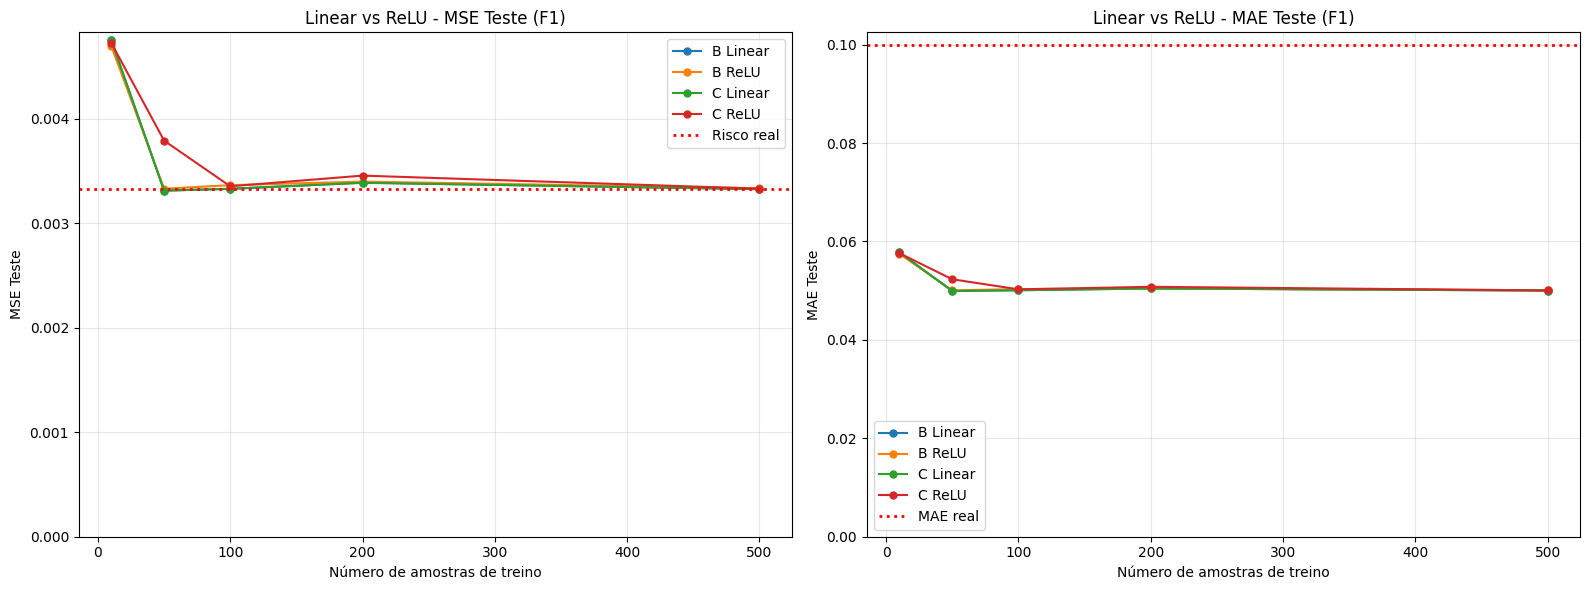

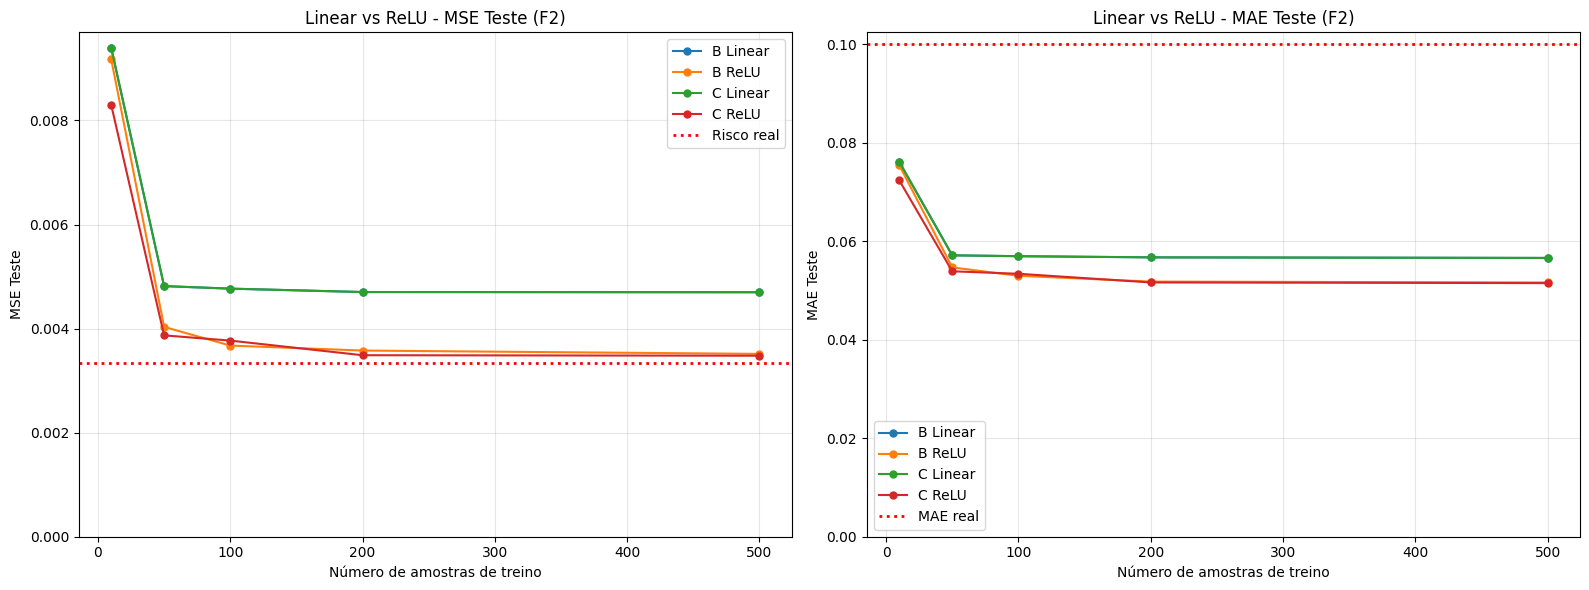

In [15]:
for func_name in ["f1", "f2"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # MSE Teste
    ax = axes[0]
    for relu_name in relu_configs:
        test_vals = [results_relu[(func_name, relu_name, n)]["test_mse"]
                     for n in SAMPLE_SIZES_EXTRA]
        ax.plot(SAMPLE_SIZES_EXTRA, test_vals, "-o", label=relu_name, markersize=5)
    ax.axhline(y=REAL_MSE, color="red", linestyle=":", linewidth=2, label="Risco real")
    ax.set_xlabel("Número de amostras de treino")
    ax.set_ylabel("MSE Teste")
    ax.set_title(f"Linear vs ReLU - MSE Teste ({func_name.upper()})")
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

    # MAE Teste
    ax = axes[1]
    for relu_name in relu_configs:
        test_vals = [results_relu[(func_name, relu_name, n)]["test_mae"]
                     for n in SAMPLE_SIZES_EXTRA]
        ax.plot(SAMPLE_SIZES_EXTRA, test_vals, "-o", label=relu_name, markersize=5)
    ax.axhline(y=REAL_MAE, color="red", linestyle=":", linewidth=2, label="MAE real")
    ax.set_xlabel("Número de amostras de treino")
    ax.set_ylabel("MAE Teste")
    ax.set_title(f"Linear vs ReLU - MAE Teste ({func_name.upper()})")
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

    fig.tight_layout()
    plt.show()

### Visualização: Predições Linear vs ReLU em f2 (N=50)

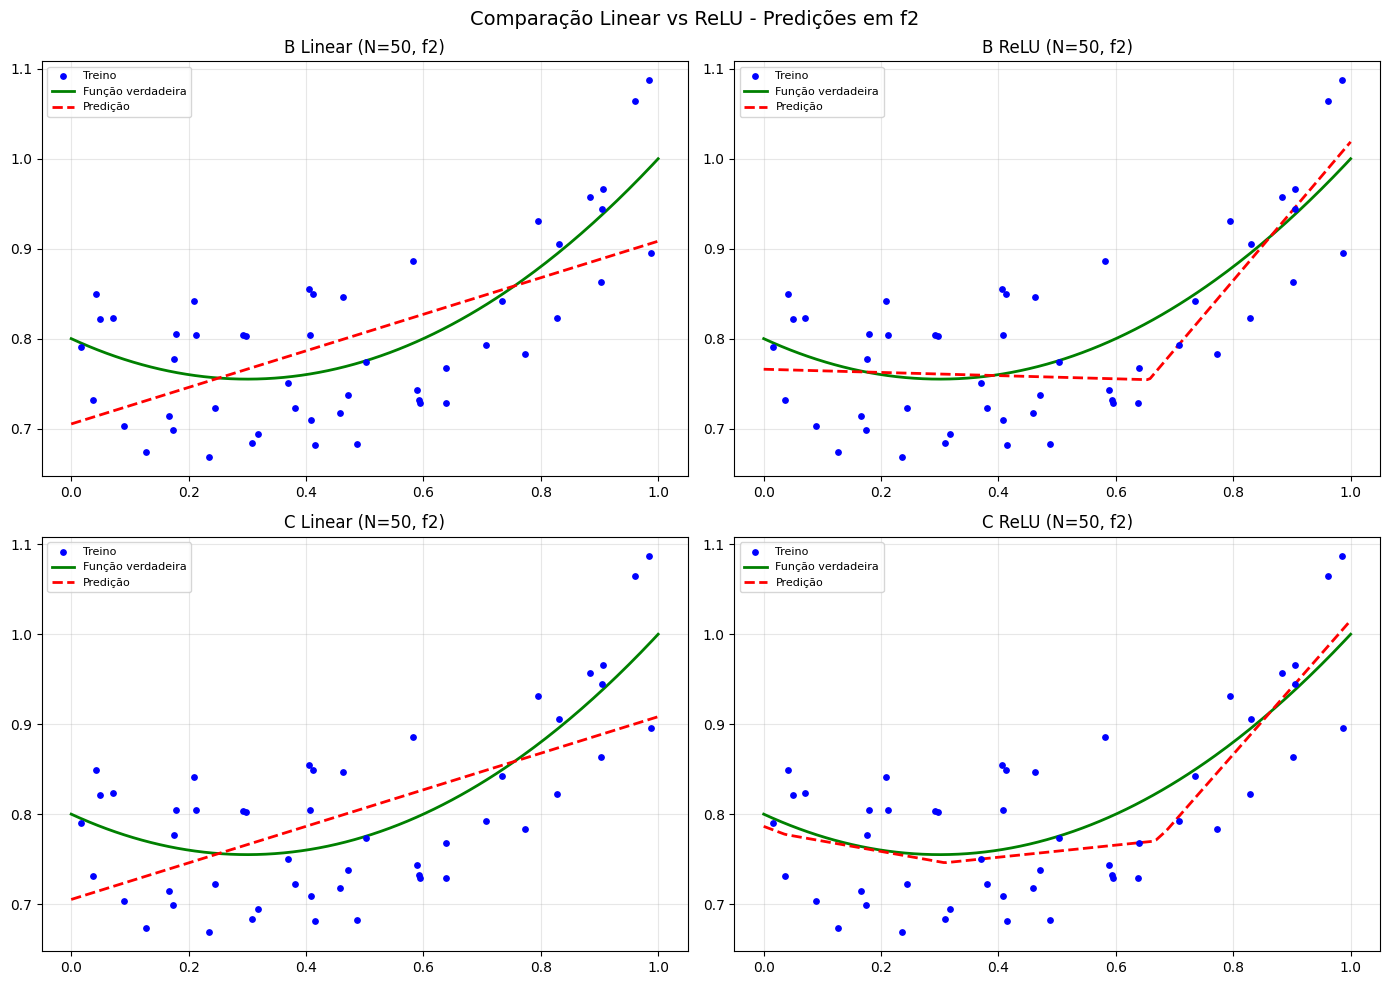

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_line = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)
y_true_f2 = 0.5 * x_line**2 - 0.3 * x_line + 0.8

for idx, (relu_name, (ModelClass, backup_state)) in enumerate(relu_configs.items()):
    ax = axes[idx // 2][idx % 2]
    x_train, y_train = datasets_f2[50]

    model = ModelClass()
    model.load_state_dict(copy.deepcopy(backup_state))
    train_model(model, x_train, y_train)

    model.eval()
    with torch.no_grad():
        y_pred = model(torch.tensor(x_line)).numpy()

    ax.scatter(x_train, y_train, color="blue", s=15, label="Treino", zorder=5)
    ax.plot(x_line, y_true_f2, "g-", linewidth=2, label="Função verdadeira")
    ax.plot(x_line, y_pred, "r--", linewidth=2, label="Predição")
    ax.set_title(f"{relu_name} (N=50, f2)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Comparação Linear vs ReLU - Predições em f2", fontsize=14)
fig.tight_layout()
plt.show()

### Profundidade com ReLU

In [17]:
deep_relu_configs = {
    "1 camada ReLU": (ModelB_ReLU, model_b_relu_backup),
    "2 camadas ReLU": (ModelDeep2_ReLU, deep2_relu_backup),
}

results_depth_relu = {}
for func_name, datasets, test_x, test_y in [
    ("f1", datasets_f1, test_x_f1, test_y_f1),
    ("f2", datasets_f2, test_x_f2, test_y_f2),
]:
    for depth_name, (ModelClass, backup_state) in deep_relu_configs.items():
        for n in SAMPLE_SIZES_EXTRA:
            x_train, y_train = datasets[n]
            model = ModelClass()
            model.load_state_dict(copy.deepcopy(backup_state))
            train_loss = train_model(model, x_train, y_train)
            test_metrics = evaluate_model(model, test_x, test_y)
            results_depth_relu[(func_name, depth_name, n)] = {
                "train_mse": train_loss,
                "test_mse": test_metrics["mse"],
                "test_mae": test_metrics["mae"],
            }
            print(f"{func_name} | {depth_name:<18} | N={n:>3d} | "
                  f"Train MSE={train_loss:.6f} | Test MSE={test_metrics['mse']:.6f}")

f1 | 1 camada ReLU      | N= 10 | Train MSE=0.001811 | Test MSE=0.004701


f1 | 1 camada ReLU      | N= 50 | Train MSE=0.003115 | Test MSE=0.003332


f1 | 1 camada ReLU      | N=100 | Train MSE=0.003260 | Test MSE=0.003366


f1 | 1 camada ReLU      | N=200 | Train MSE=0.002982 | Test MSE=0.003400


f1 | 1 camada ReLU      | N=500 | Train MSE=0.003199 | Test MSE=0.003337


...

f2 | 2 camadas ReLU     | N= 10 | Train MSE=0.003191 | Test MSE=0.007905


f2 | 2 camadas ReLU     | N= 50 | Train MSE=0.003566 | Test MSE=0.003951


f2 | 2 camadas ReLU     | N=100 | Train MSE=0.003221 | Test MSE=0.003718


f2 | 2 camadas ReLU     | N=200 | Train MSE=0.003220 | Test MSE=0.003534


f2 | 2 camadas ReLU     | N=500 | Train MSE=0.003656 | Test MSE=0.003501


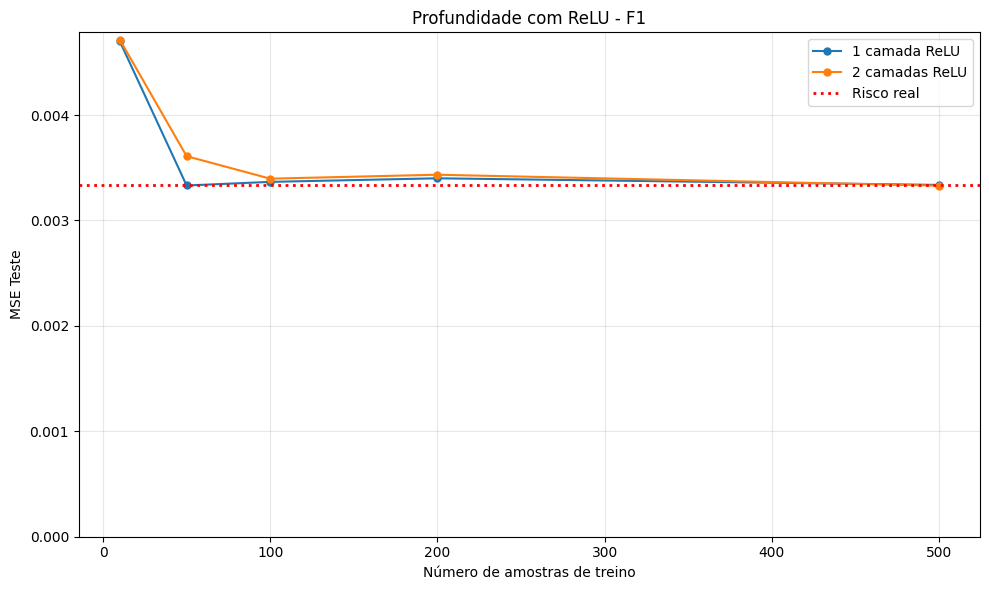

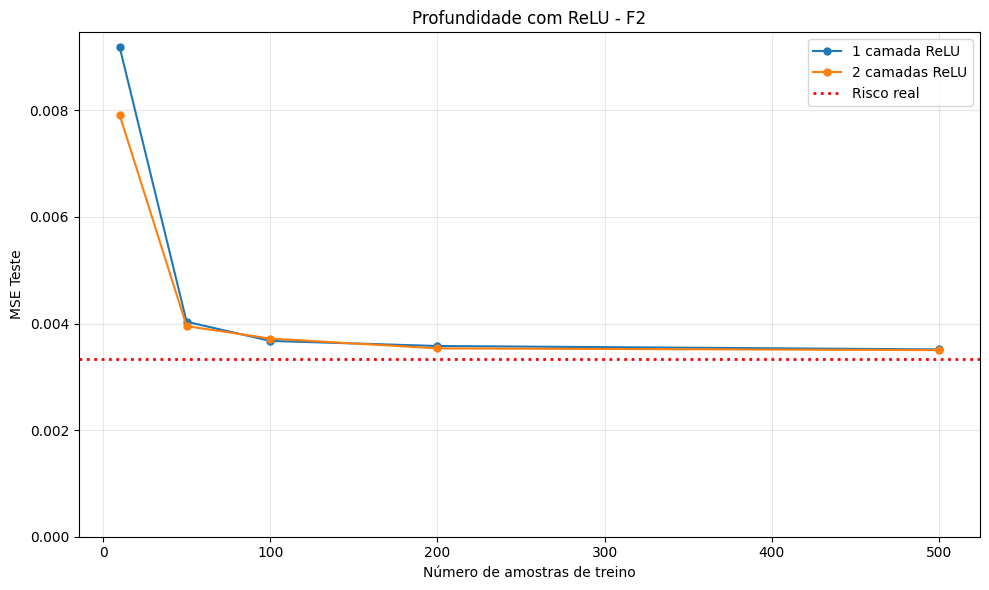

In [18]:
for func_name in ["f1", "f2"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    for depth_name in deep_relu_configs:
        test_vals = [results_depth_relu[(func_name, depth_name, n)]["test_mse"]
                     for n in SAMPLE_SIZES_EXTRA]
        ax.plot(SAMPLE_SIZES_EXTRA, test_vals, "-o", label=depth_name, markersize=5)
    ax.axhline(y=REAL_MSE, color="red", linestyle=":", linewidth=2, label="Risco real")
    ax.set_xlabel("Número de amostras de treino")
    ax.set_ylabel("MSE Teste")
    ax.set_title(f"Profundidade com ReLU - {func_name.upper()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    plt.show()

### Análise: Impacto da mudança para ReLU

A ativação ReLU (`max(0, x)`) transforma a rede em um **aproximador universal de funções** (pelo Teorema da Aproximação Universal), permitindo capturar relações não-lineares. Cada neurônio com ReLU cria uma "dobradiça" — uma transição linear por partes — e a combinação de muitas dobradiças pode aproximar qualquer função contínua.

**Resultados observados:**

#### f1 (função linear)
- **Pouca ou nenhuma melhora em relação ao linear.** A função geradora já é linear, então os modelos lineares já eram adequados. A ReLU não prejudica significativamente (a rede pode aprender a usar os neurônios na região linear da ReLU), mas também não traz ganho.
- Com poucos dados, a ReLU pode até introduzir **overfitting leve**, pois a rede tem mais capacidade expressiva do que o necessário para uma função linear.

#### f2 (função quadrática)
- **Melhora significativa**, especialmente com o Modelo C ReLU (30 neurônios). Os gráficos de predição mostram claramente: enquanto os modelos lineares traçam uma reta, o C ReLU consegue aproximar a curvatura da parábola com uma função linear por partes.
- O Modelo B ReLU (2 neurônios) tem melhora modesta — com apenas 2 dobradiças, a aproximação da parábola é limitada.
- Com **poucos dados + muita capacidade** (C ReLU, N pequeno), pode-se observar **overfitting**: o loss de treino é baixo mas o loss de teste é alto, pois a rede memoriza os poucos pontos em vez de aprender o padrão geral.

#### Comparação Linear vs ReLU nos gráficos MSE e MAE
- Para f2, observe a **separação clara** entre as curvas dos modelos ReLU (abaixo) e lineares (acima), especialmente com mais dados. Isso evidencia que o ganho da ReLU é de **redução de viés** — o modelo agora consegue representar a função verdadeira.
- O C ReLU com dados suficientes (N ≥ 100) se aproxima do risco real, algo que nenhum modelo linear consegue.

### Profundidade + ReLU

Com ReLU, adicionar camadas **agora sim** aumenta a capacidade expressiva, diferente do caso linear. Cada camada pode criar regiões lineares por partes mais refinadas:
- Uma camada com k neurônios ReLU cria até k regiões lineares.
- Duas camadas podem criar até k² regiões, permitindo aproximações muito mais finas.

Nos gráficos de profundidade com ReLU, a rede de 2 camadas ReLU tende a ter desempenho igual ou melhor que a de 1 camada para f2, demonstrando que profundidade + não-linearidade é uma combinação efetiva para aumentar a capacidade de aproximação.

---
## Conclusão Geral

### Síntese dos achados

Este trabalho explorou a relação entre erro de treino e erro de generalização sob diferentes configurações de modelo, quantidade de dados e funções de ativação. Os principais achados são:

1. **Modelos lineares (A, B, C com ativação identidade)** são matematicamente equivalentes independentemente do número de neurônios. A composição de transformações lineares é linear. Isso implica que adicionar neurônios ou camadas sem não-linearidade **não aumenta a capacidade expressiva**.

2. **Fitting adequado vs Underfitting:** Para f1 (linear), os modelos lineares são adequados e convergem ao risco irredutível. Para f2 (quadrática), os mesmos modelos apresentam underfitting permanente — o viés do modelo é o fator limitante, e mais dados não resolvem o problema.

3. **O papel da quantidade de amostras:** Mais dados reduzem o gap de generalização (componente de variância), mas não eliminam o viés do modelo. A distinção entre viés e variância é fundamental: dados resolvem problemas de variância, mas apenas modelos mais expressivos resolvem problemas de viés.

4. **Profundidade sem não-linearidade é inútil:** Empilhar camadas lineares não muda a classe de funções que o modelo pode representar. Na prática, pode até piorar os resultados por dificultar a otimização (gradientes instáveis).

5. **ReLU desbloqueia a capacidade das redes:** Com ativação ReLU, os modelos ganham capacidade de aproximar funções não-lineares. O Modelo C ReLU (30 neurônios) consegue aproximar a função quadrática f2 com erro próximo ao risco irredutível, algo impossível para qualquer modelo linear.

6. **Profundidade + ReLU é efetivo:** Diferente do caso linear, adicionar camadas com ReLU aumenta genuinamente a capacidade expressiva, pois cada camada multiplica o número de regiões lineares por partes.

### Relação entre os três riscos

| Risco | Definição | Relação com os experimentos |
|-------|-----------|----------------------------|
| **Empírico (treino)** | Loss calculado nos dados de treino | Subestima o erro real; diminui com mais parâmetros/capacidade |
| **Simulado (1000 amostras)** | Loss em dados não vistos | Aproximação confiável do erro real de generalização |
| **Real (irredutível)** | MSE ≈ 0.00333, MAE = 0.1 | Piso teórico que nenhum modelo pode ultrapassar |

O risco empírico sempre é ≤ simulado (o modelo é otimizado para os dados de treino). A diferença entre eles é o **gap de generalização**. O risco simulado converge ao real apenas quando o modelo é adequado (viés correto) e tem dados suficientes (variância baixa).

In [19]:
print("=" * 60)
print("EXECUÇÃO CONCLUÍDA COM SUCESSO!")
print("=" * 60)

EXECUÇÃO CONCLUÍDA COM SUCESSO!
